In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.chdir("/mnt/aix22301/onj")


def plot_log(file):
    # Load the log file
    with open(f"./log/{file}/log.txt", "r") as f:
        lines = f.readlines()

    # Initialize dictionaries to store parsed values by stream
    streams = {}  # train epoch
    streams2 = {}  # norm valid
    streams3 = {}  # lr auroc

    # Parse the lines, grouping by stream types
    for line in lines:
        step, stream, val, stream2, val2, stream3, val3 = line.strip().split()
        step = int(step)
        val, val2, val3 = float(val), float(val2), float(val3)

        if stream not in streams:
            streams[stream] = {}
        if stream2 not in streams2:
            streams2[stream2] = {}
        if stream3 not in streams3:
            streams3[stream3] = {}

        streams[stream][step] = val
        streams2[stream2][step] = val2
        streams3[stream3][step] = val3

    # Convert streams to sorted lists for plotting
    def convert_to_xy(stream):
        return {k: list(zip(*sorted(v.items()))) for k, v in stream.items()}

    streams_xy = convert_to_xy(streams)
    streams2_xy = convert_to_xy(streams2)
    streams3_xy = convert_to_xy(streams3)

    # Plotting
    num_x, num_y = (2, 2)
    fig, axes = plt.subplots(num_x, num_y, figsize=(16, 12))

    # Plot loss and metric
    plt.subplot(num_x, num_y, 1)
    xs, ys = streams_xy["train"]
    plt.plot(xs, ys, label="train loss")

    xs, ys = streams2_xy["valid"]
    plt.plot(xs, ys, label="valid loss")

    xs, ys = streams3_xy["auroc"]
    plt.plot(xs, ys, label="auroc")
    print("Max auroc:", max(ys))

    plt.xlabel("steps")
    plt.ylabel("Cross-Entropy Loss")
    plt.ylim(top=1.2, bottom=0.0)
    plt.legend()
    plt.title("Loss and Metric")

    # Baseline lines
    plt.axhline(y=0.8, color="r", linestyle="--", label="baseline")
    plt.axhline(y=2.0, color="g", linestyle="--", label="baseline")
    plt.axhline(y=0.5, color="b", linestyle="--", label="baseline")

    # Plot gradient norm and learning rate
    plt.subplot(num_x, num_y, 2)
    xs, ys = streams3_xy["lr"]
    ys = np.array(ys) * 1e7  # Convert to NumPy array before scaling
    plt.plot(xs, ys, label="lr")
    plt.xlabel("steps")
    plt.ylabel("Norm Scale (ignore lr scale)")
    plt.ylim(top=100, bottom=0.0)

    xs, ys = streams2_xy["norm"]
    plt.plot(xs, ys, label="norm")
    plt.legend()
    plt.title("Gradient Norm and LR")

    # Plot learning rate
    plt.subplot(num_x, num_y, 3)
    xs, ys = streams3_xy["lr"]
    ys = np.array(ys)  # Convert to NumPy array for consistent plotting
    plt.plot(xs, ys, label="lr")
    plt.legend()
    plt.title("Learning Rate")

    # Plot gradient norm
    plt.subplot(num_x, num_y, 4)
    xs, ys = streams2_xy["norm"]
    ys = np.array(ys)  # Convert to NumPy array for consistent plotting
    plt.plot(xs, ys, label="norm")
    plt.legend()
    plt.title("Gradient Norm")

    plt.tight_layout()
    plt.show()


# Usage example:
# plot_log("2024-11-04_14-59-47_n_embed_512_n_head_8_n_class_2_n_layer_3_n_patch3d_(16, 16, 8)_n_patch2d_(64, 64)_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_200_lr_1e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None")

Max auroc: 0.803125


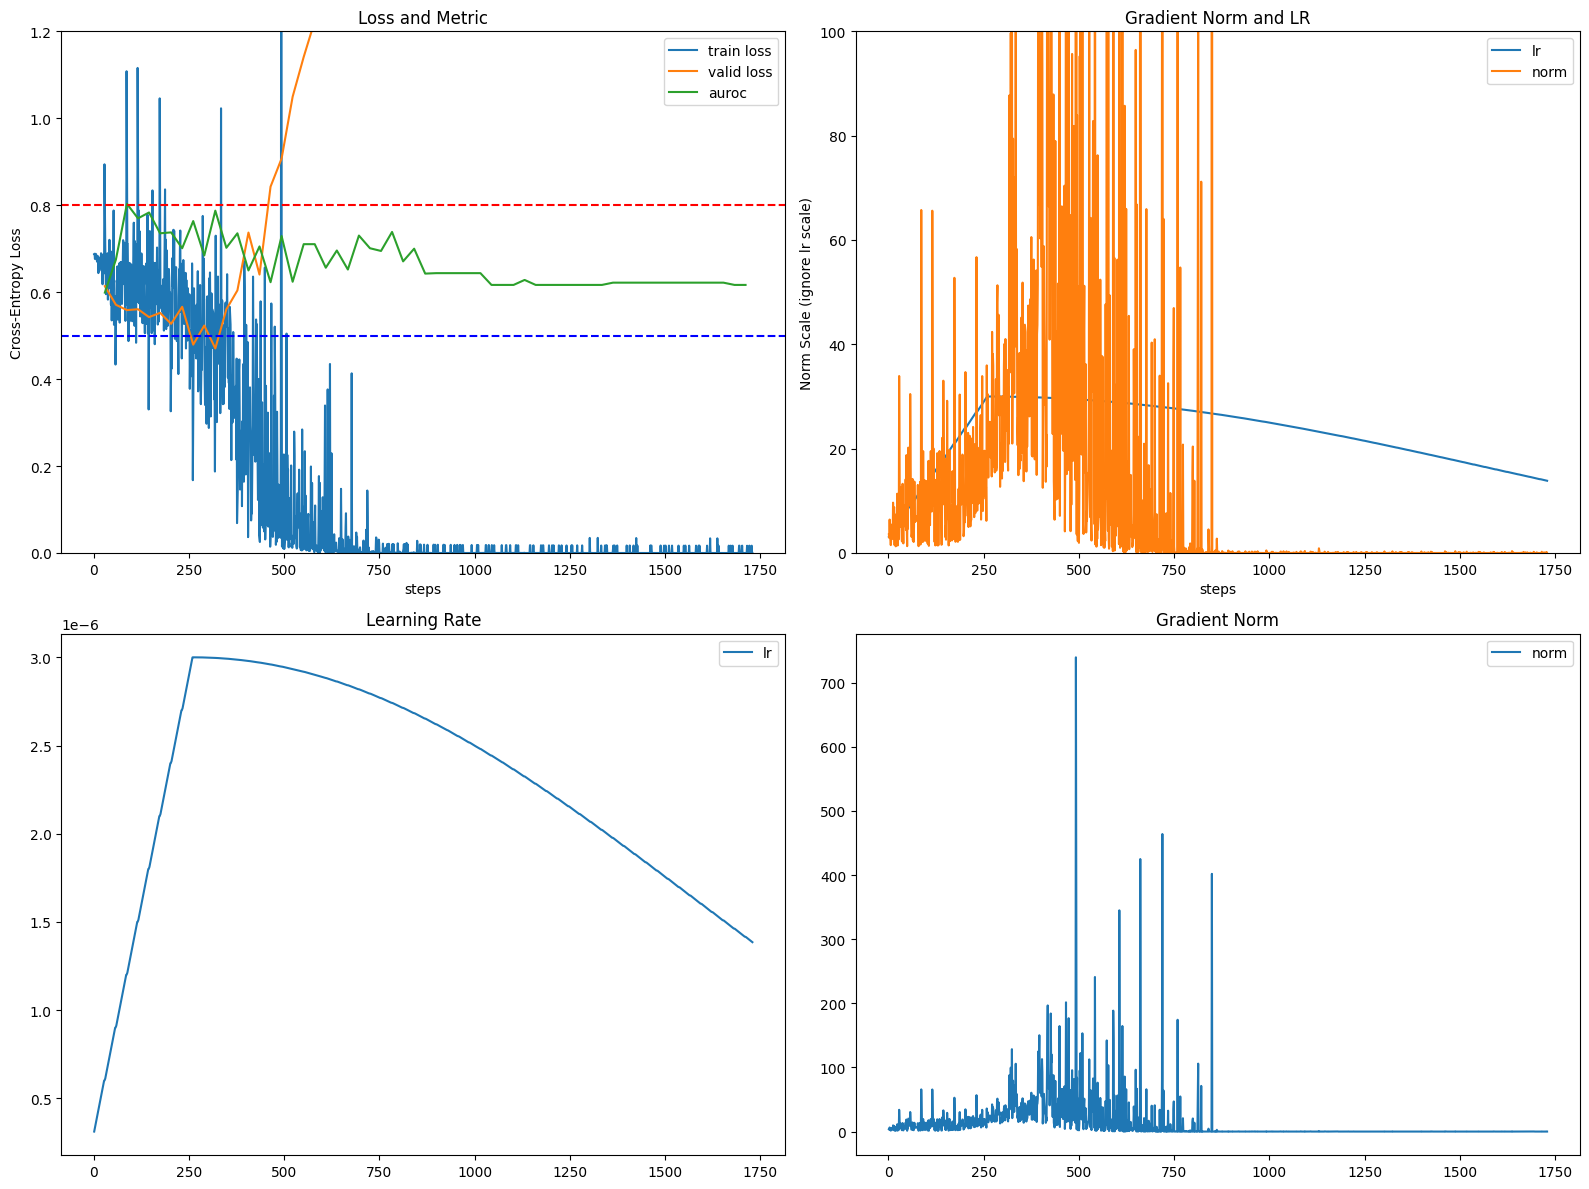

In [2]:
# plot high feature fusion
plot_log(
    "2024-11-04_10-30-58_resume_False_lr_3e-06_gpu_7_layer_4_batch_16_epochs_100_patch3d_(16, 16, 8)_patch2d_(64, 64)_embed_512_head_8_width2d_1024_width3d_512"
)

Max auroc: 0.7020833333333334


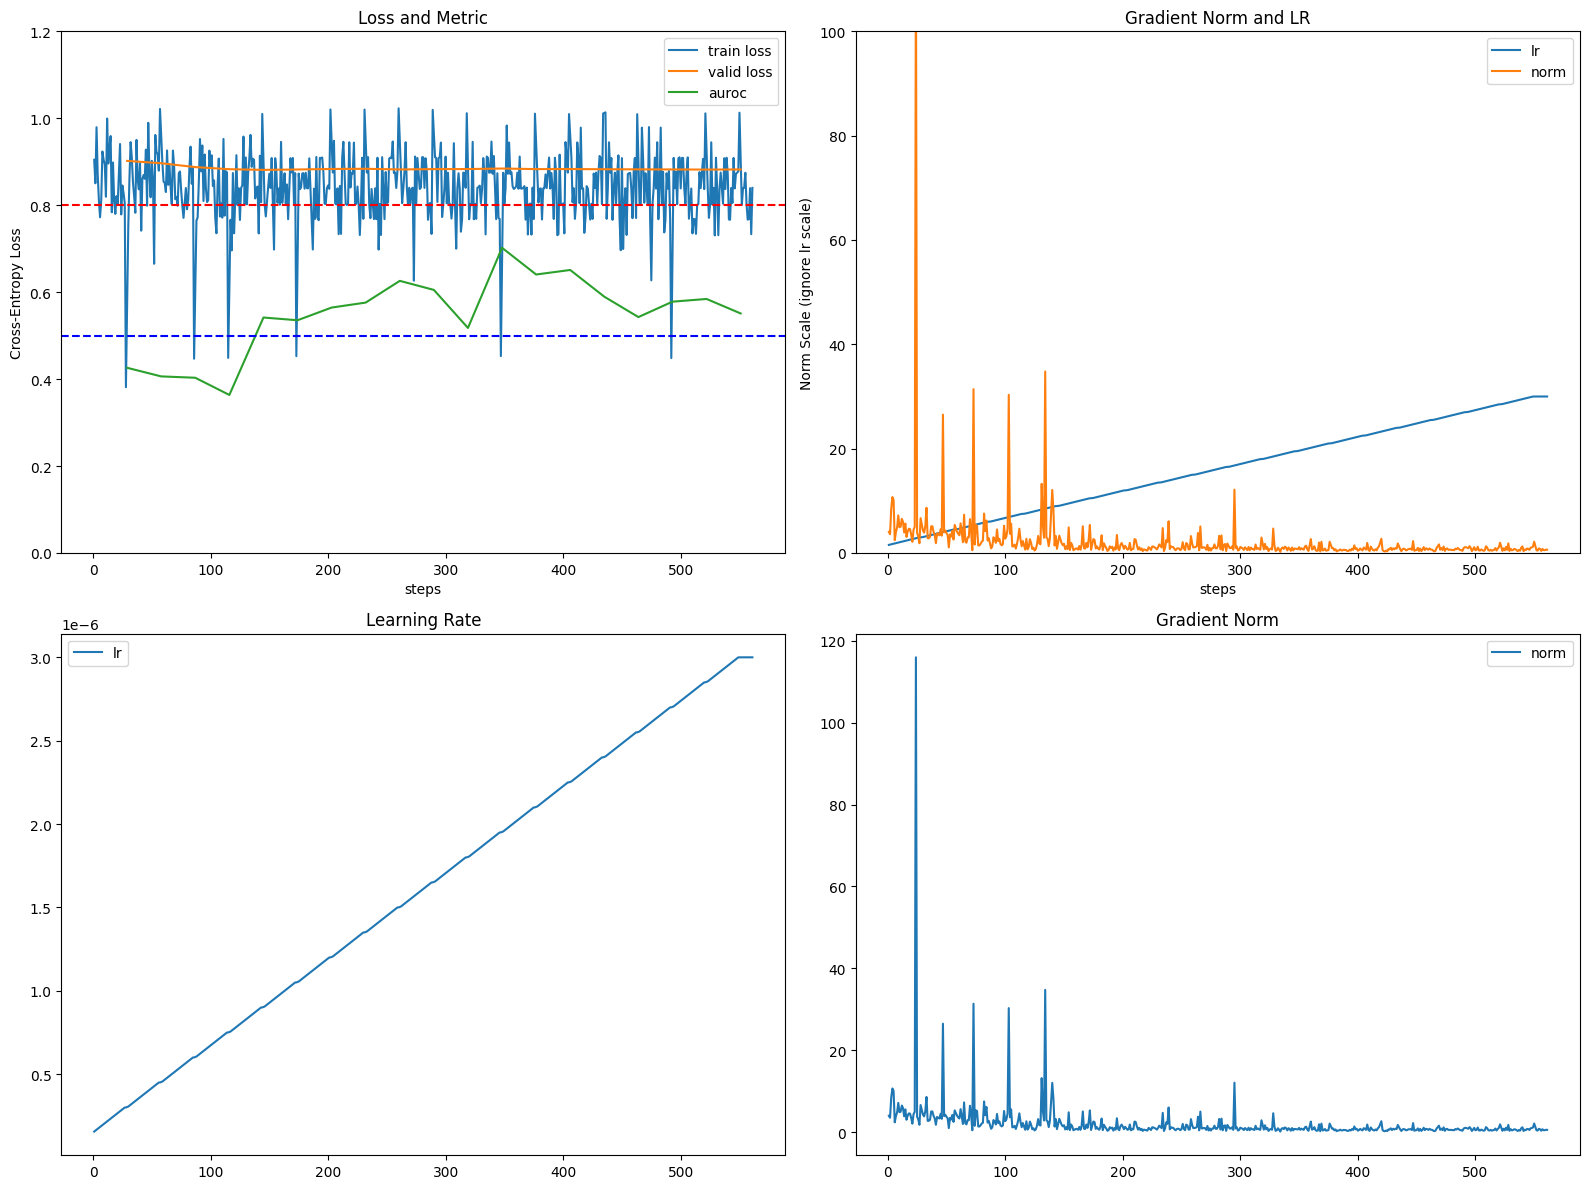

In [3]:
plot_log(
    "2025-02-10_10-51-24_n_embed_256_n_head_4_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_7_lambda1_0.0_lambda2_1.0_epochs_200_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.7906249999999999


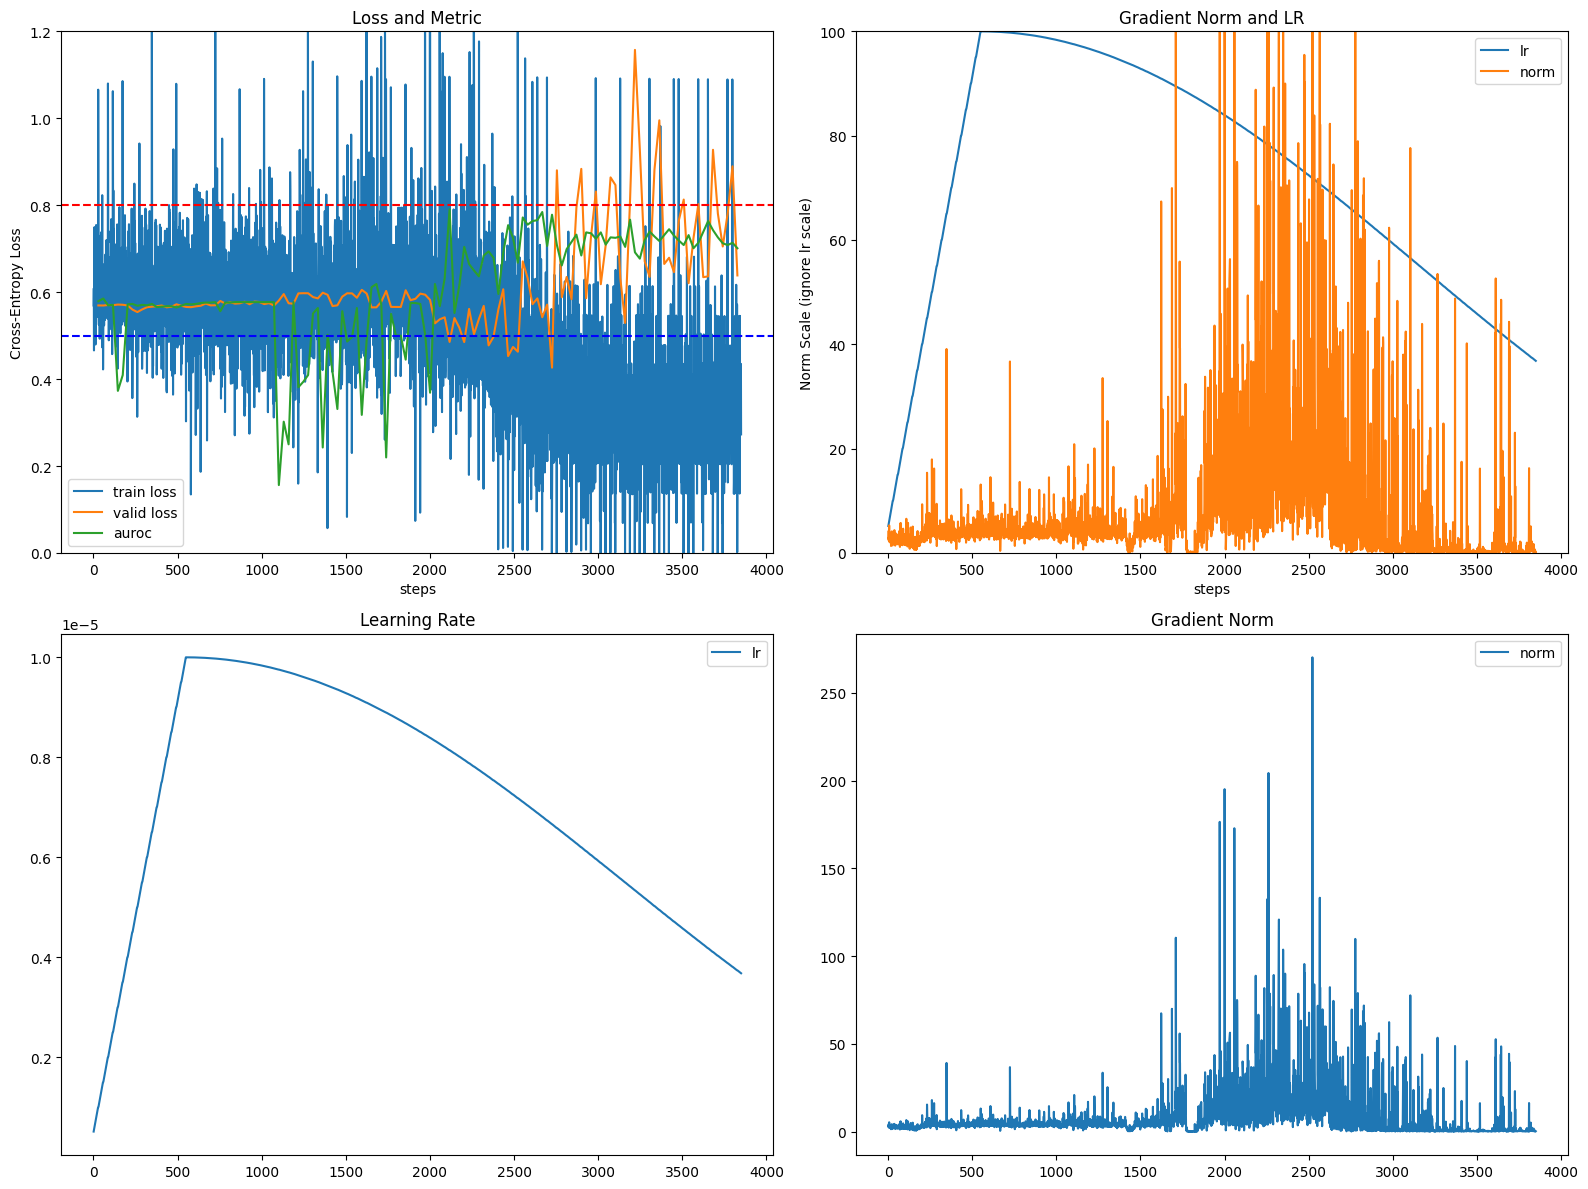

In [ ]:
# plot high feature fusion
plot_log(
    "2025-01-19_16-21-47_n_embed_512_n_head_8_n_class_1_n_layer_2_n_patch3d_(16, 16, 8)_n_patch2d_(64, 64)_width_2d_1024_width_3d_512_gpu_7_lambda1_0.0_lambda2_1.0_epochs_200_lr_1e-05_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.8166666666666667


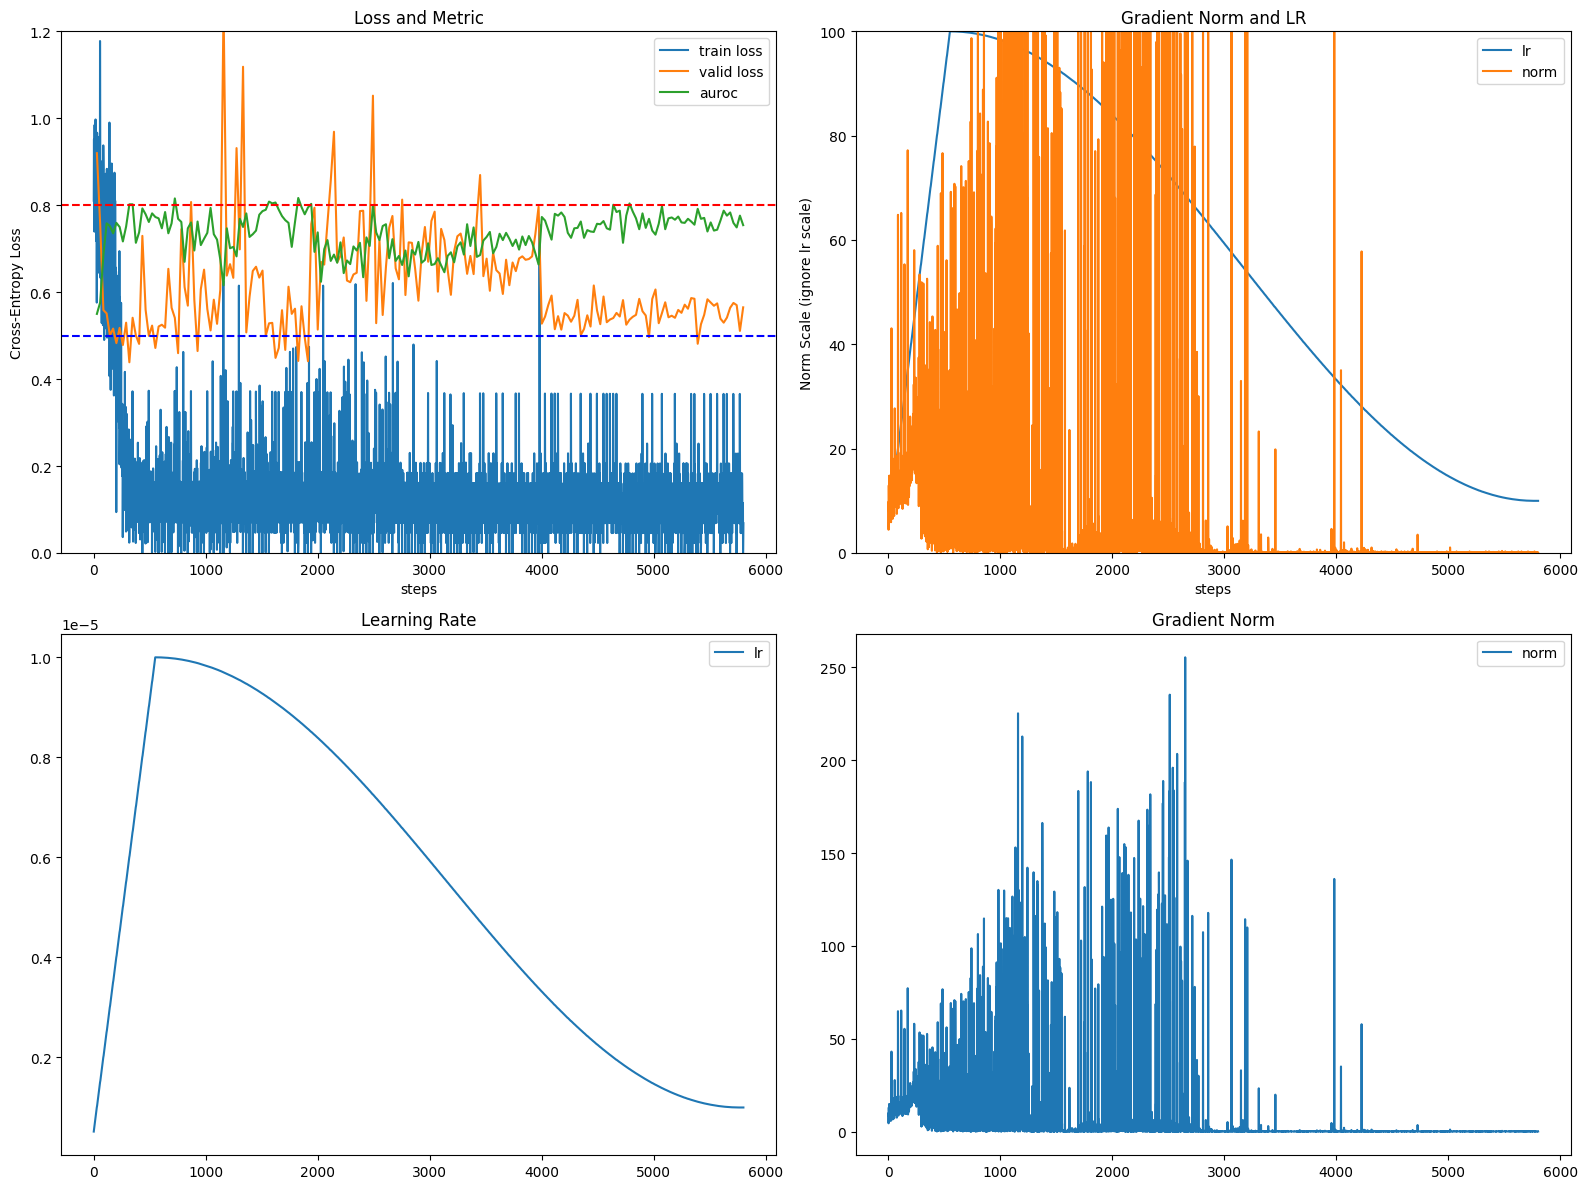

In [ ]:
plot_log(
    "2025-01-20_16-49-48_n_embed_512_n_head_8_n_class_1_n_layer_2_n_patch3d_(16, 16, 8)_n_patch2d_(64, 64)_width_2d_1024_width_3d_512_gpu_7_lambda1_0.0_lambda2_1.0_epochs_200_lr_1e-05_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.8729166666666668


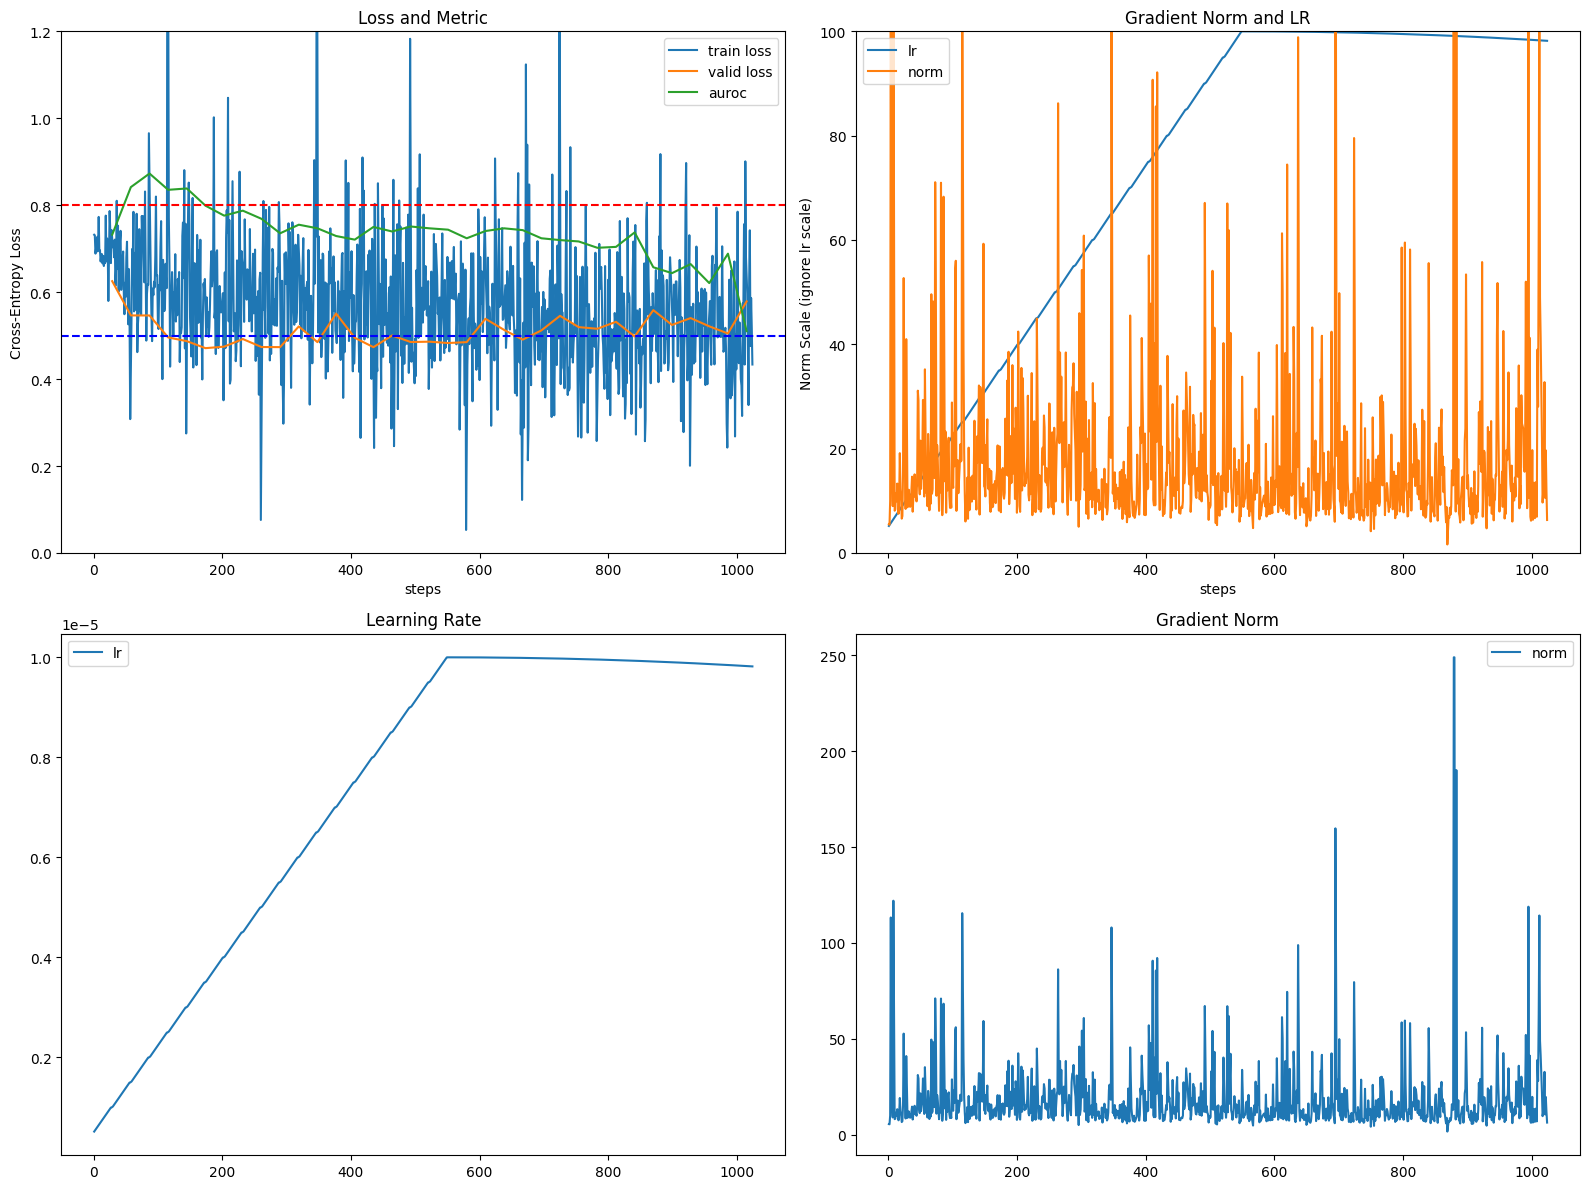

In [2]:
# plot high feature fusion
plot_log(
    "2025-02-10_18-39-30_n_embed_256_n_head_4_n_class_1_n_layer_1_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_200_lr_1e-05_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.8541666666666667


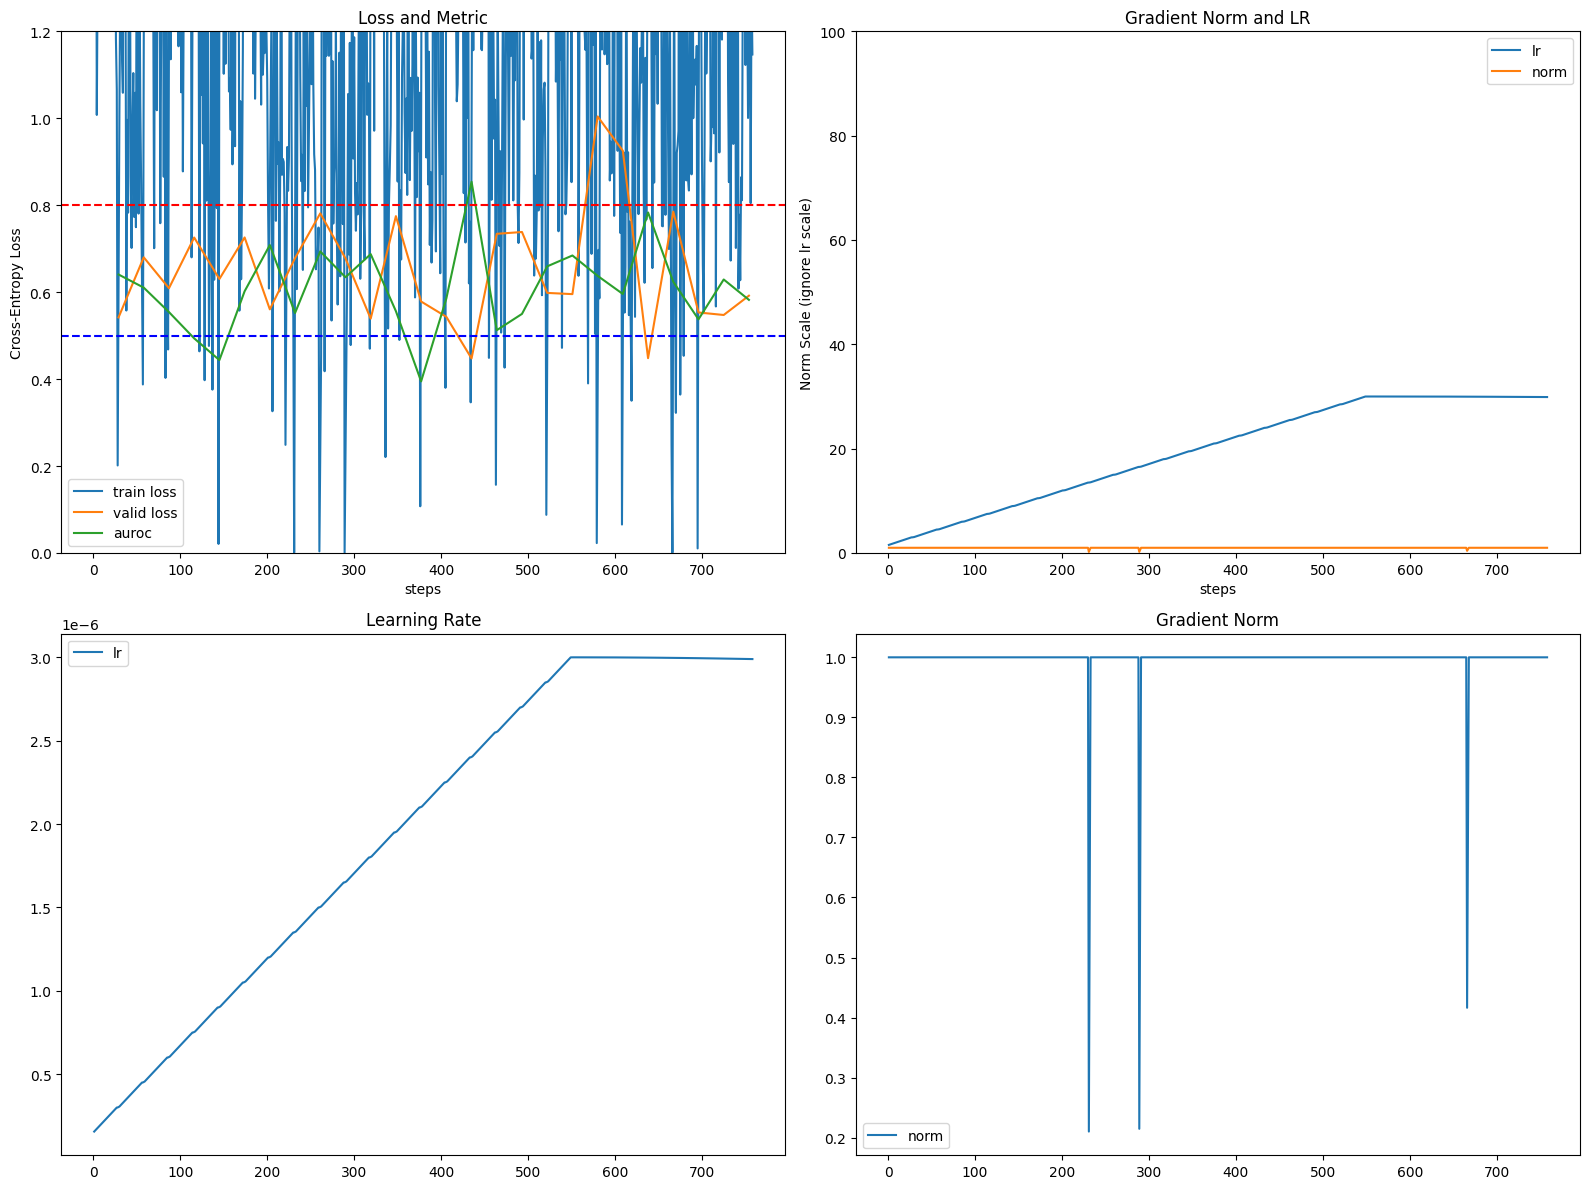

In [9]:
plot_log(
    "2025-02-10_21-53-52_debug_False_n_embed_256_n_head_4_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_200_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.825


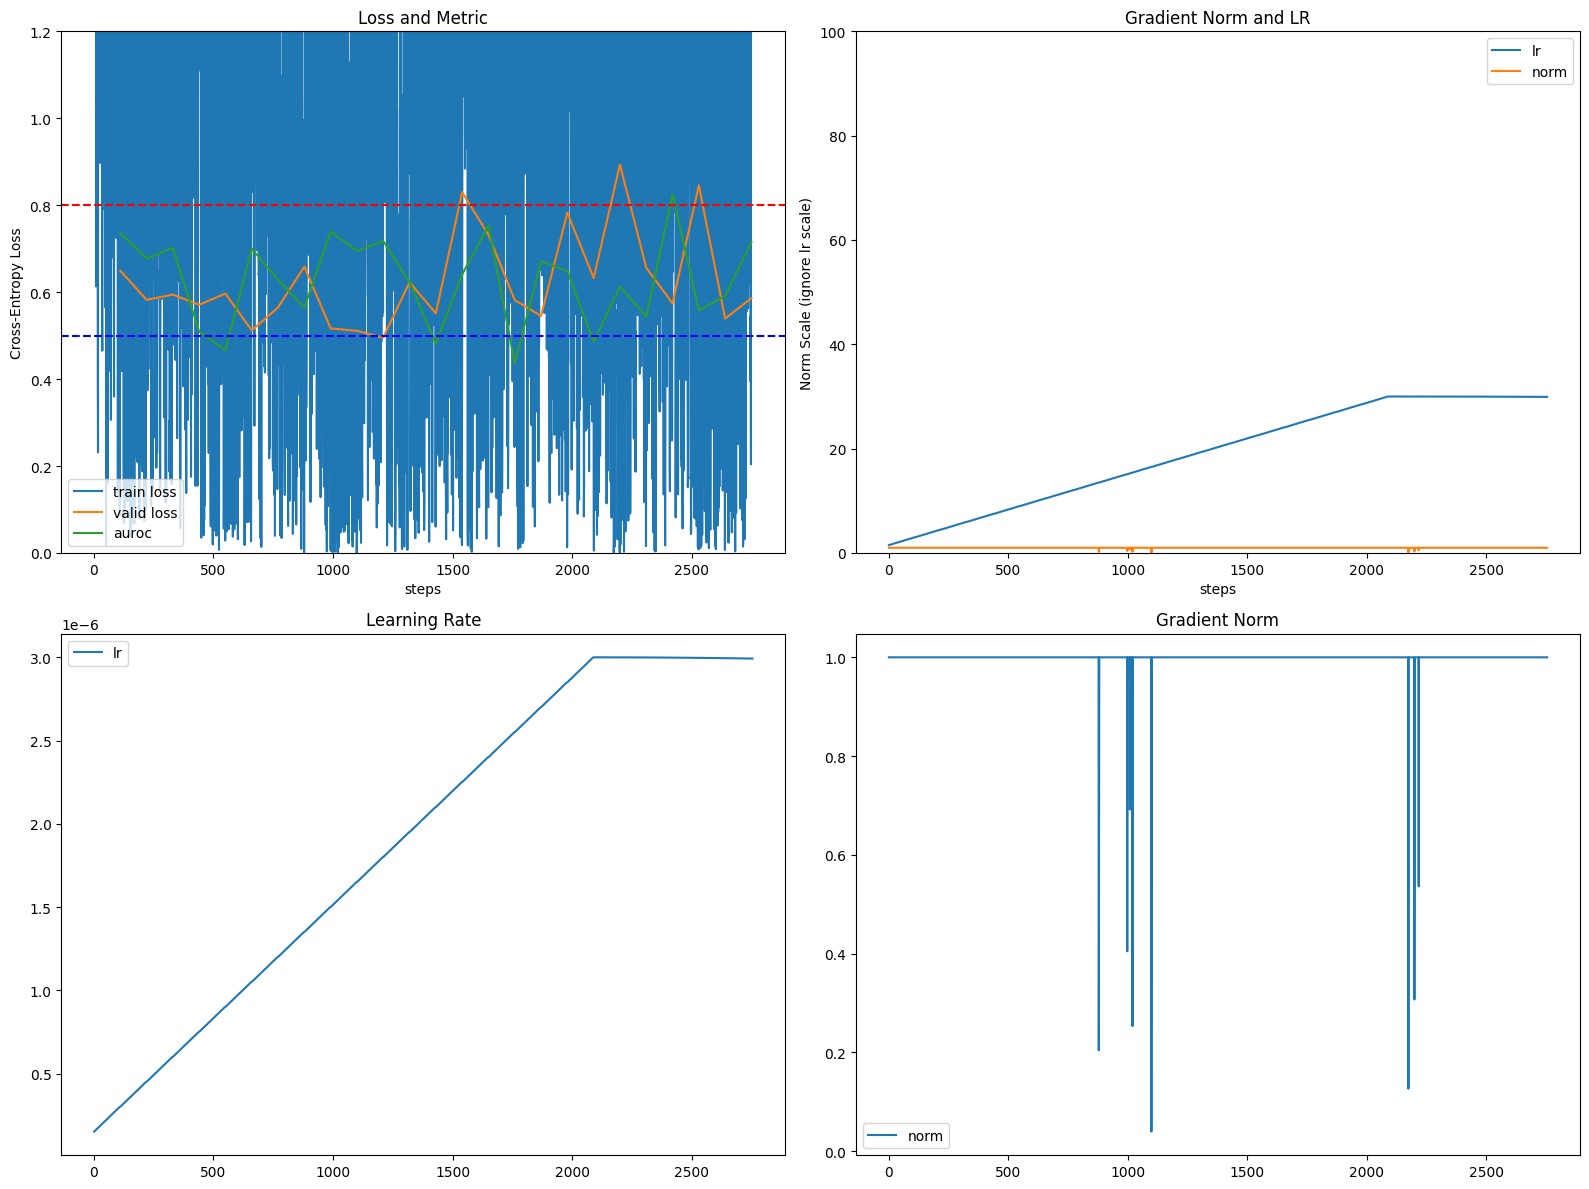

In [91]:
plot_log(
    "2025-02-10_21-50-27_debug_True_n_embed_256_n_head_4_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_7_lambda1_0.0_lambda2_1.0_epochs_200_lr_3e-06_batch_1_grad_accum_steps_4_eps_1e-06_resume_None"
)

Max auroc: 0.790625


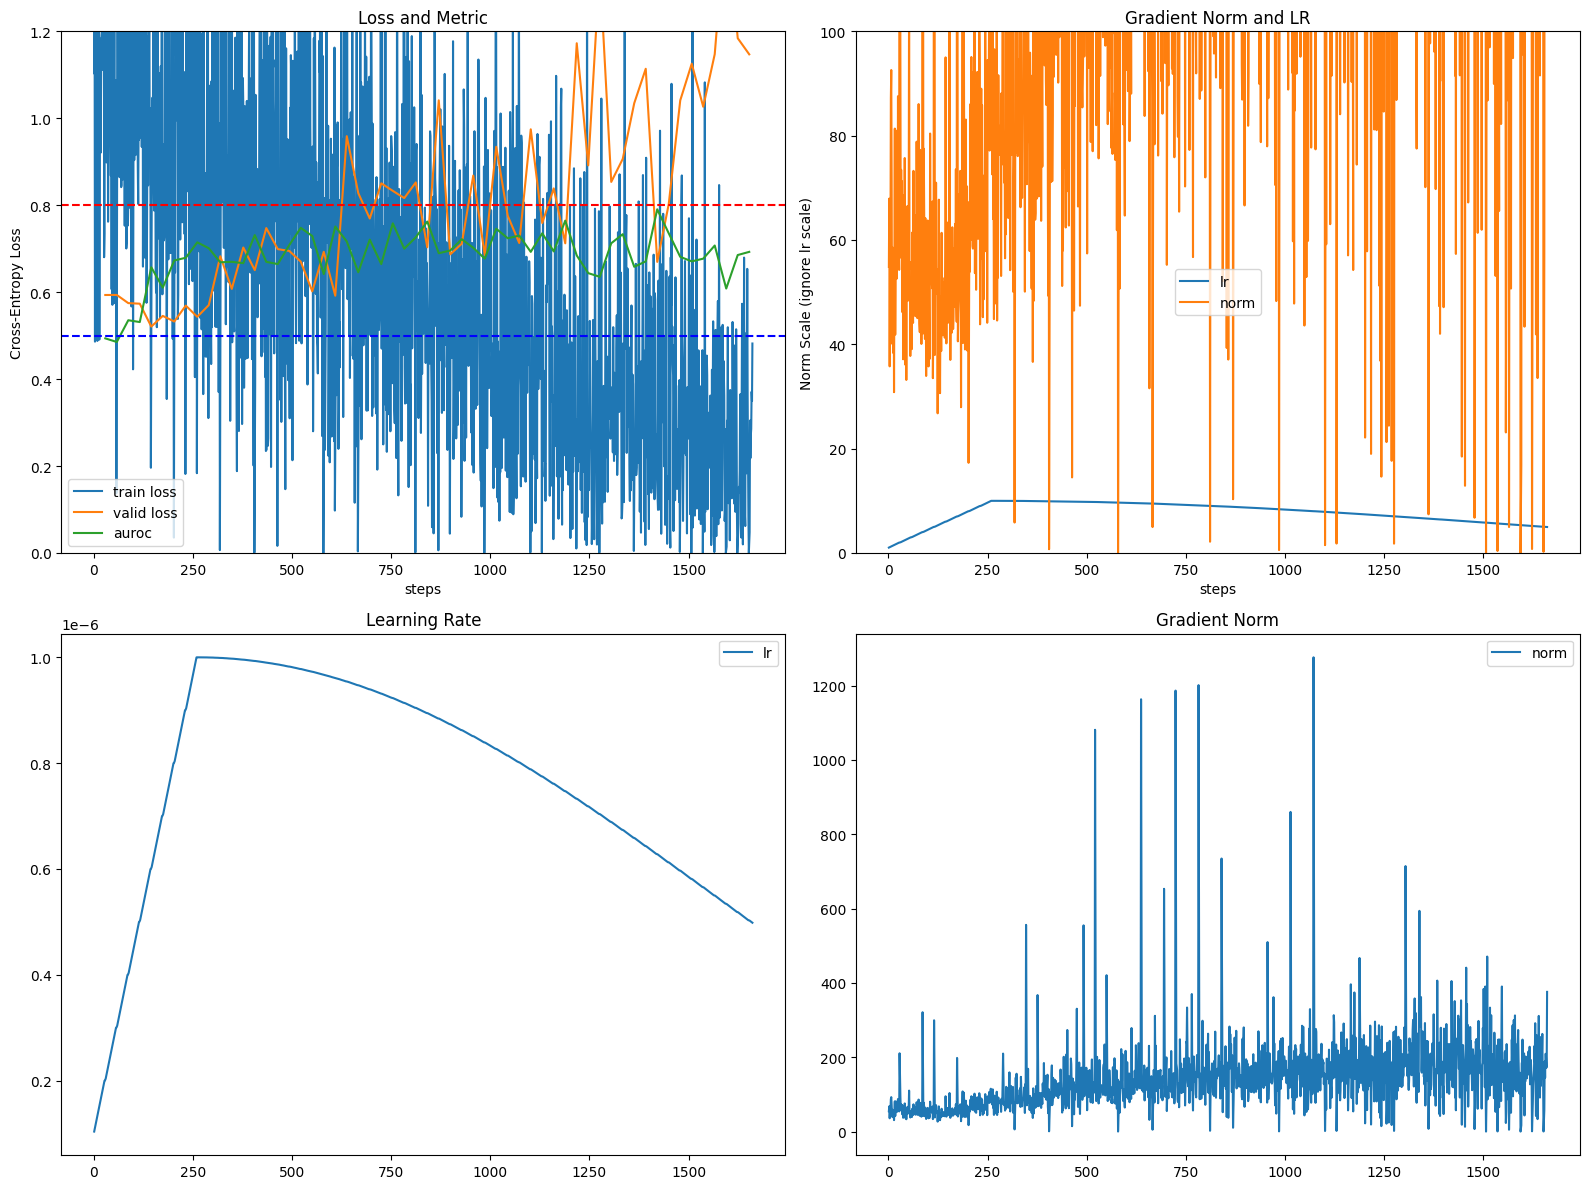

In [19]:
plot_log(
    "2025-02-11_13-03-24_debug_False_n_embed_256_n_head_4_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_100_lr_1e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.8020833333333334


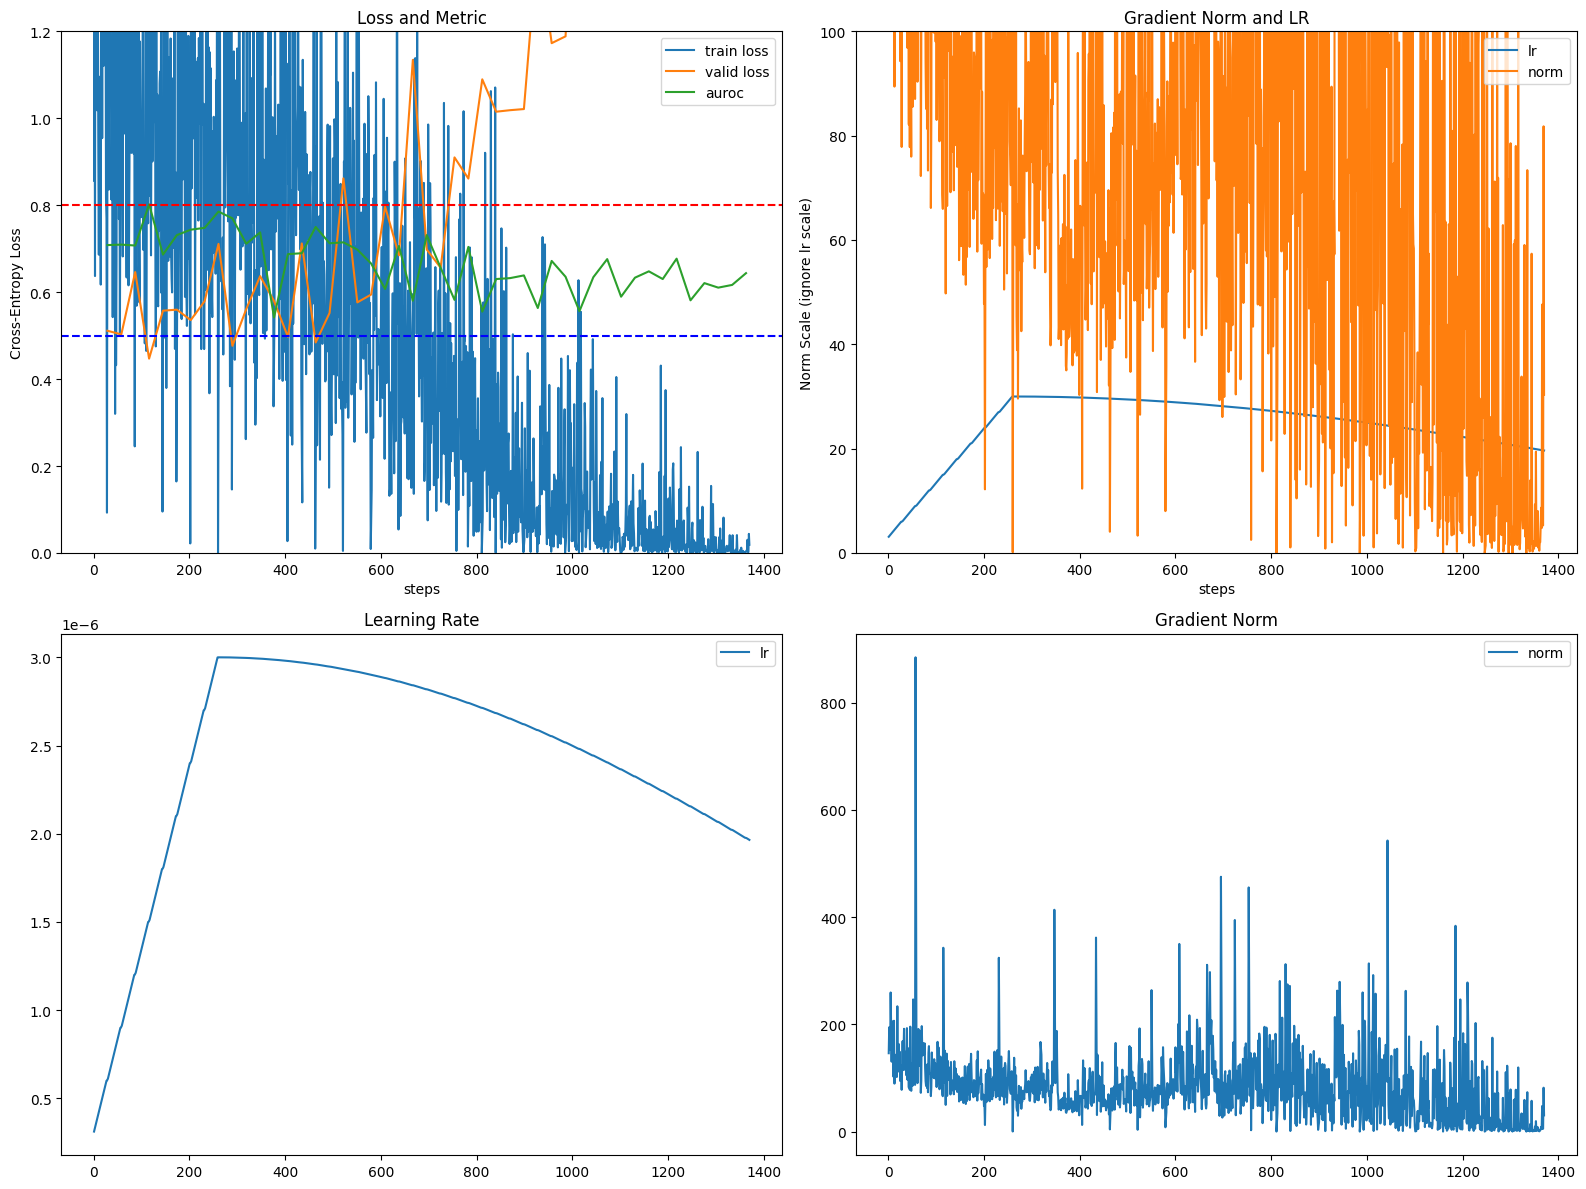

In [22]:
plot_log(
    "2025-02-11_16-56-07_debug_False_n_embed_256_n_head_8_n_class_1_n_layer_6_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_100_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.7677083333333333


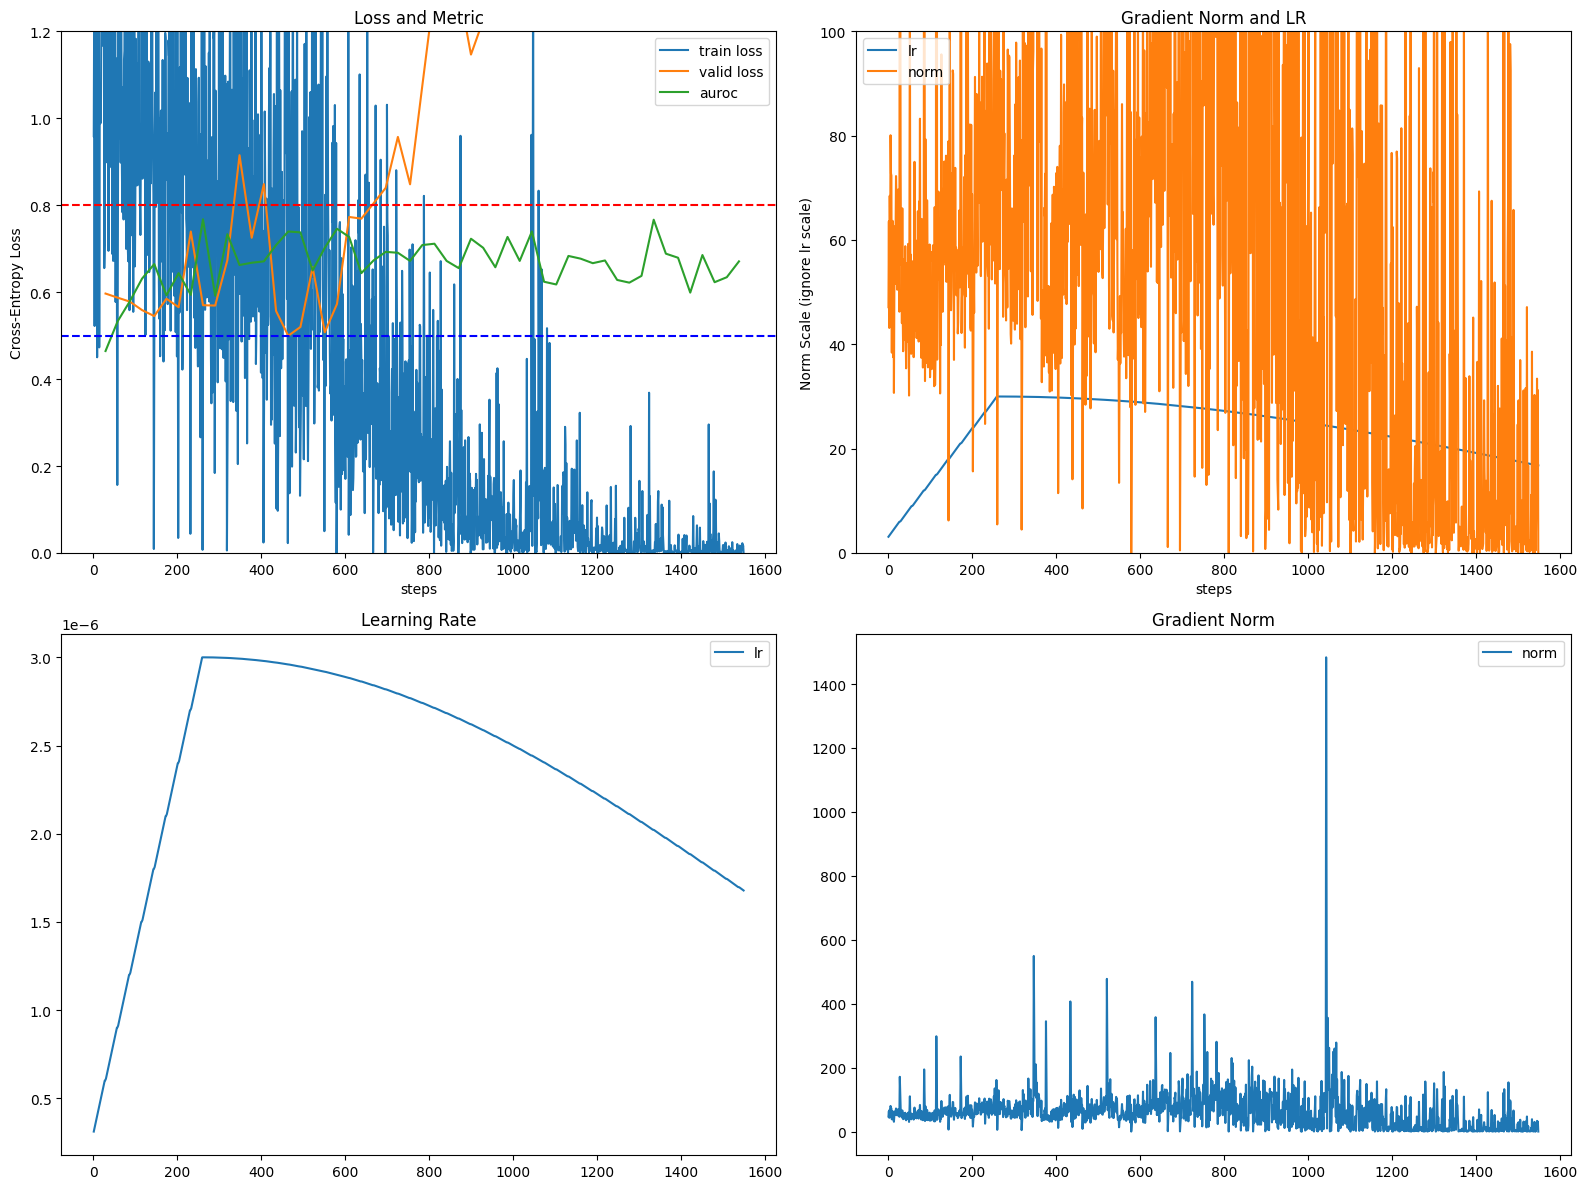

In [6]:
plot_log(
    "2025-02-11_14-38-13_debug_True_n_embed_256_n_head_8_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_7_lambda1_0.0_lambda2_1.0_epochs_100_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.5


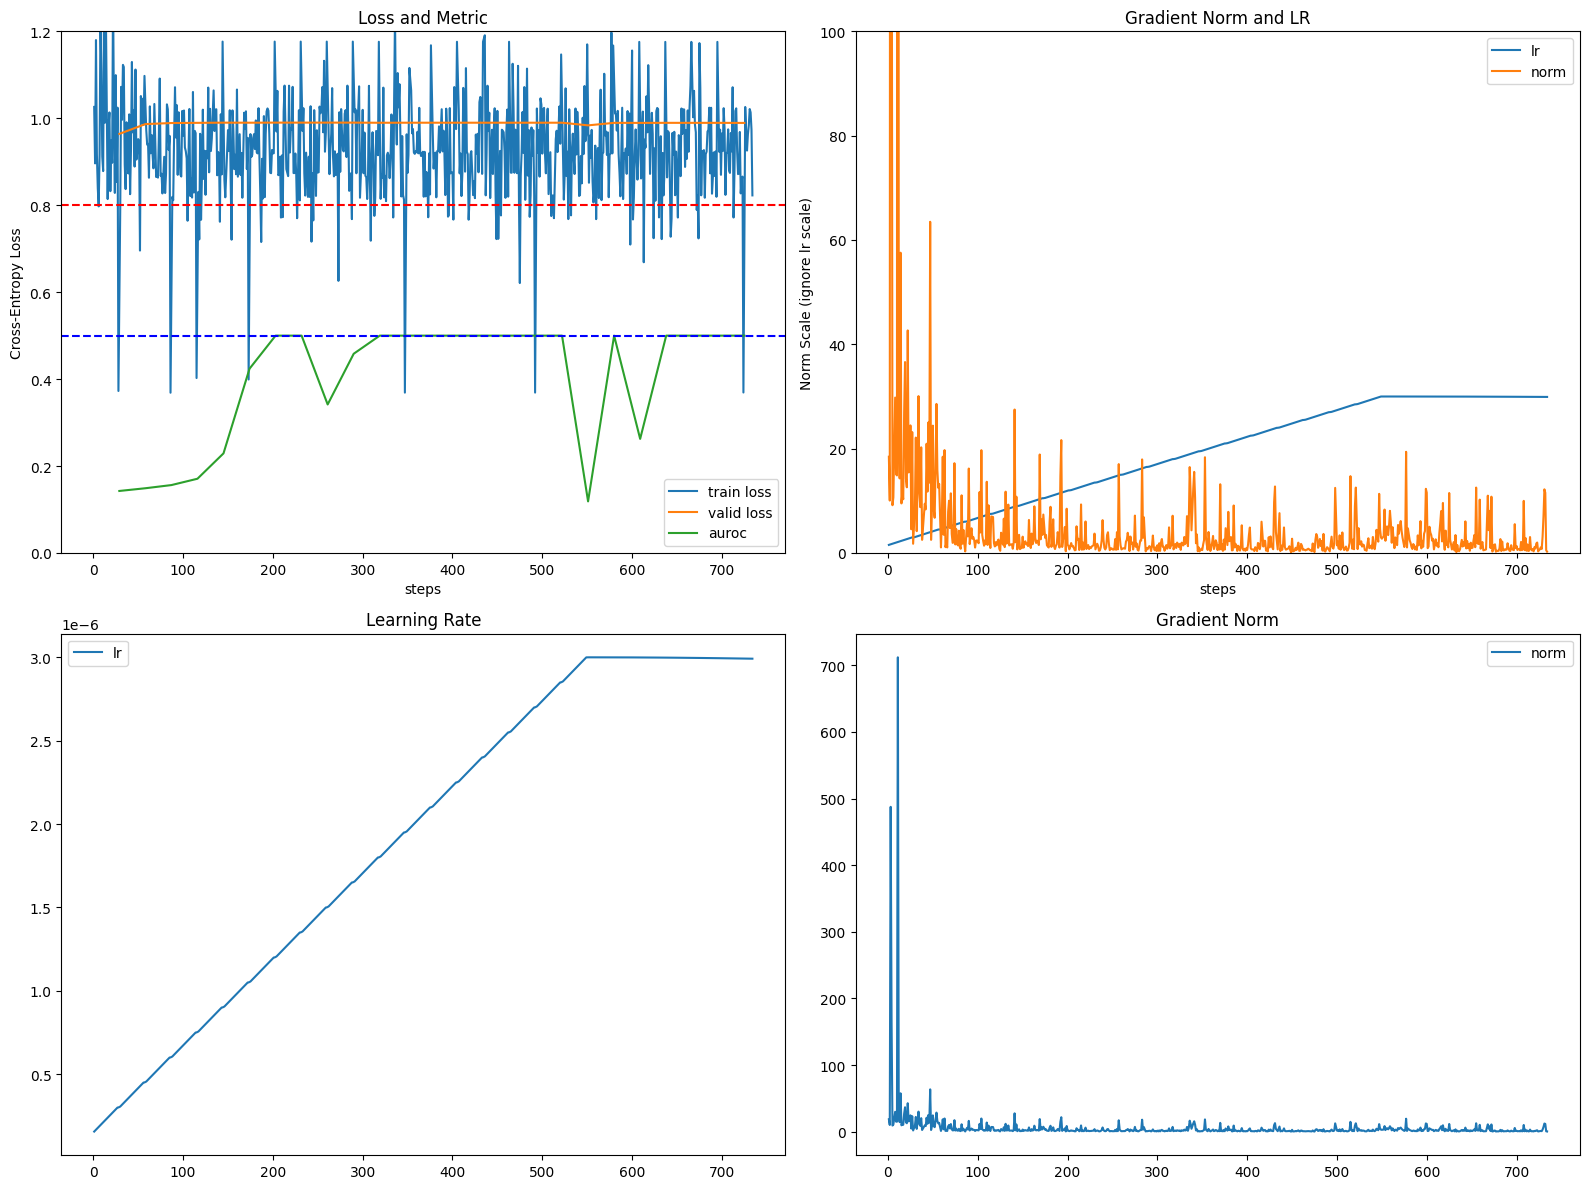

In [17]:
plot_log(
    "2025-02-10_00-05-08_n_embed_512_n_head_8_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_7_lambda1_0.0_lambda2_1.0_epochs_200_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.6812499999999999


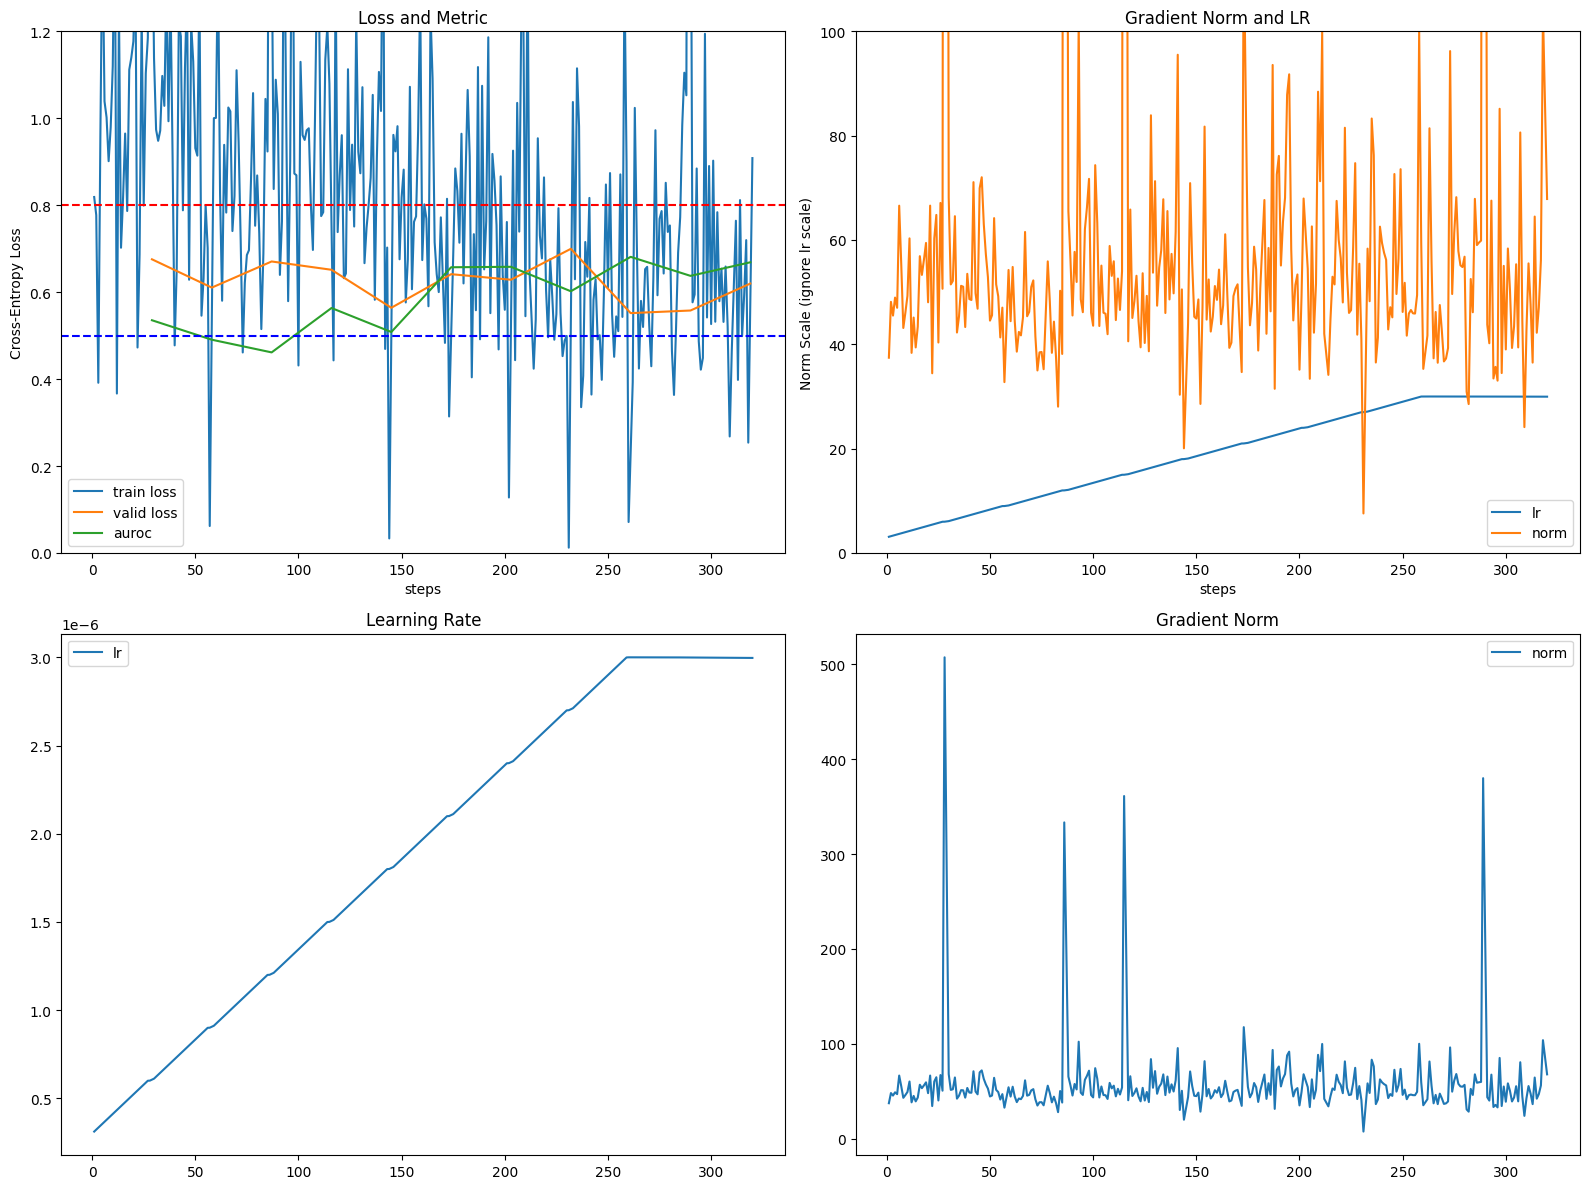

In [18]:
plot_log(
    "2025-02-12_17-26-20_debug_True_n_embed_256_n_head_4_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_100_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.7635416666666668


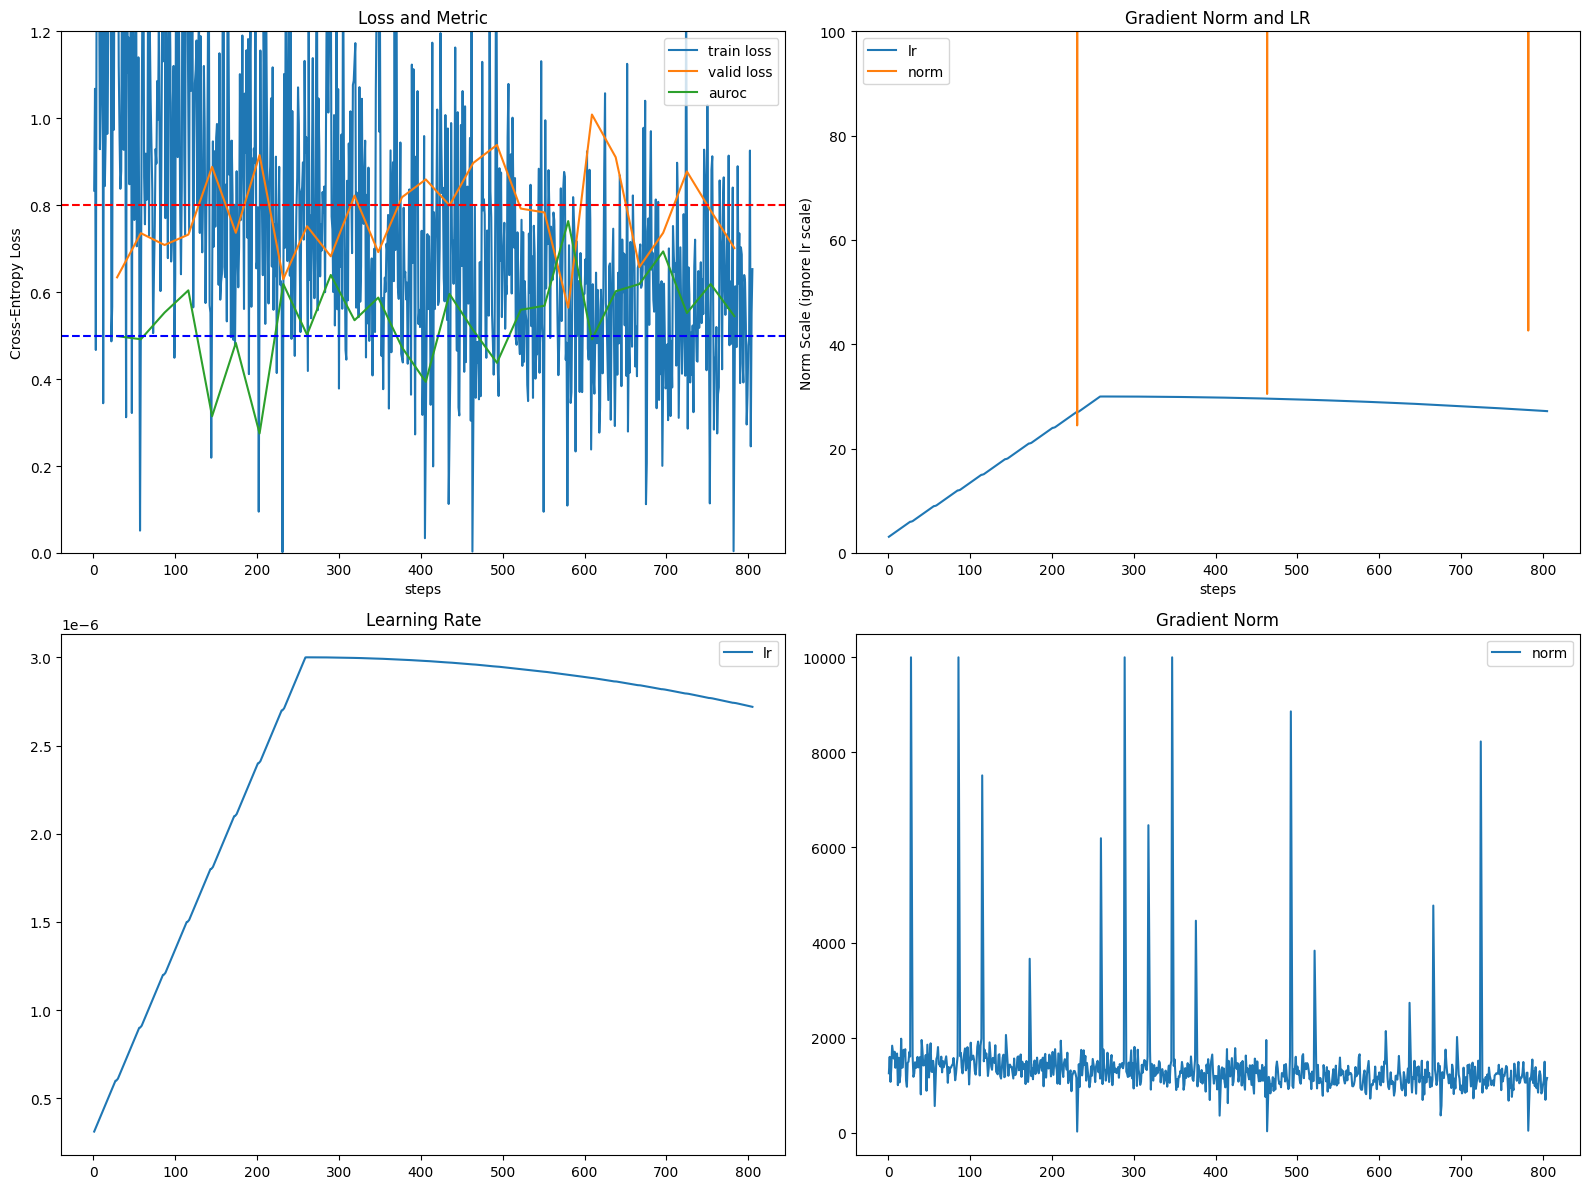

In [22]:
plot_log(
    "2025-02-12_23-05-41_debug_True_n_embed_256_n_head_4_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_100_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.6885416666666667


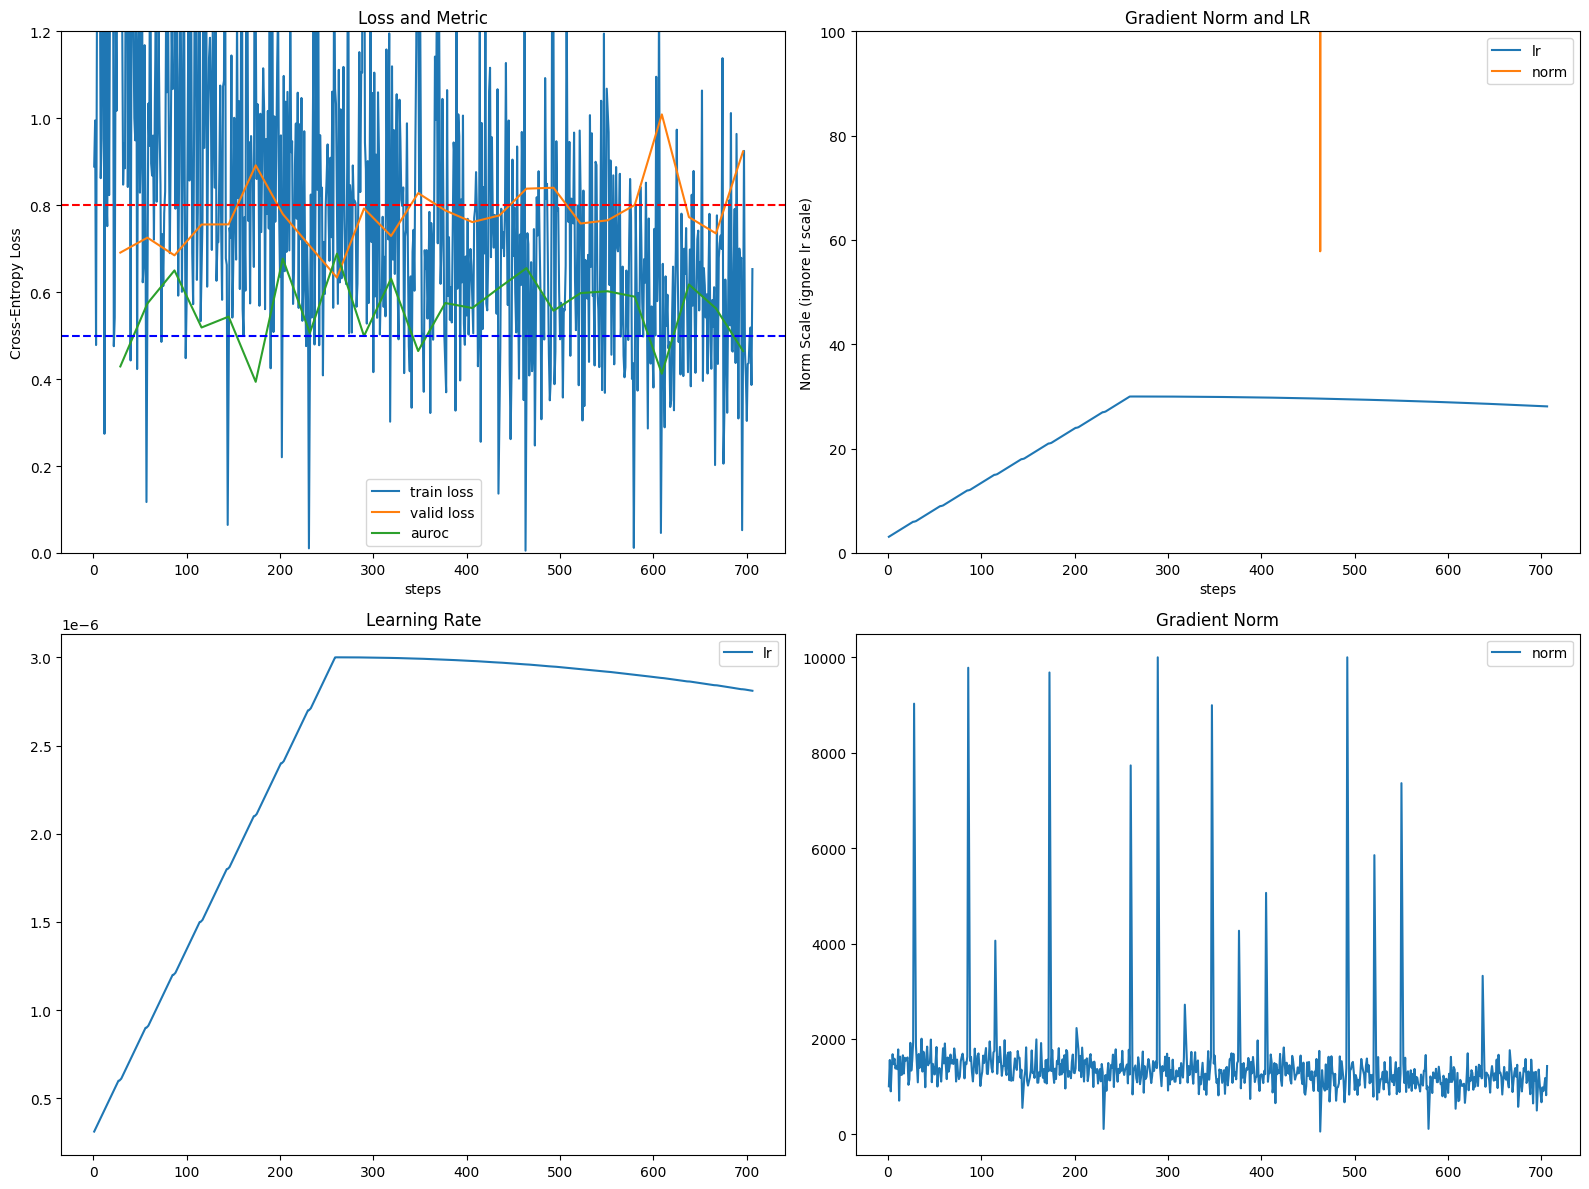

In [59]:
plot_log(
    "2025-02-12_23-06-23_debug_True_n_embed_256_n_head_8_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_7_lambda1_0.0_lambda2_1.0_epochs_100_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.5354166666666667


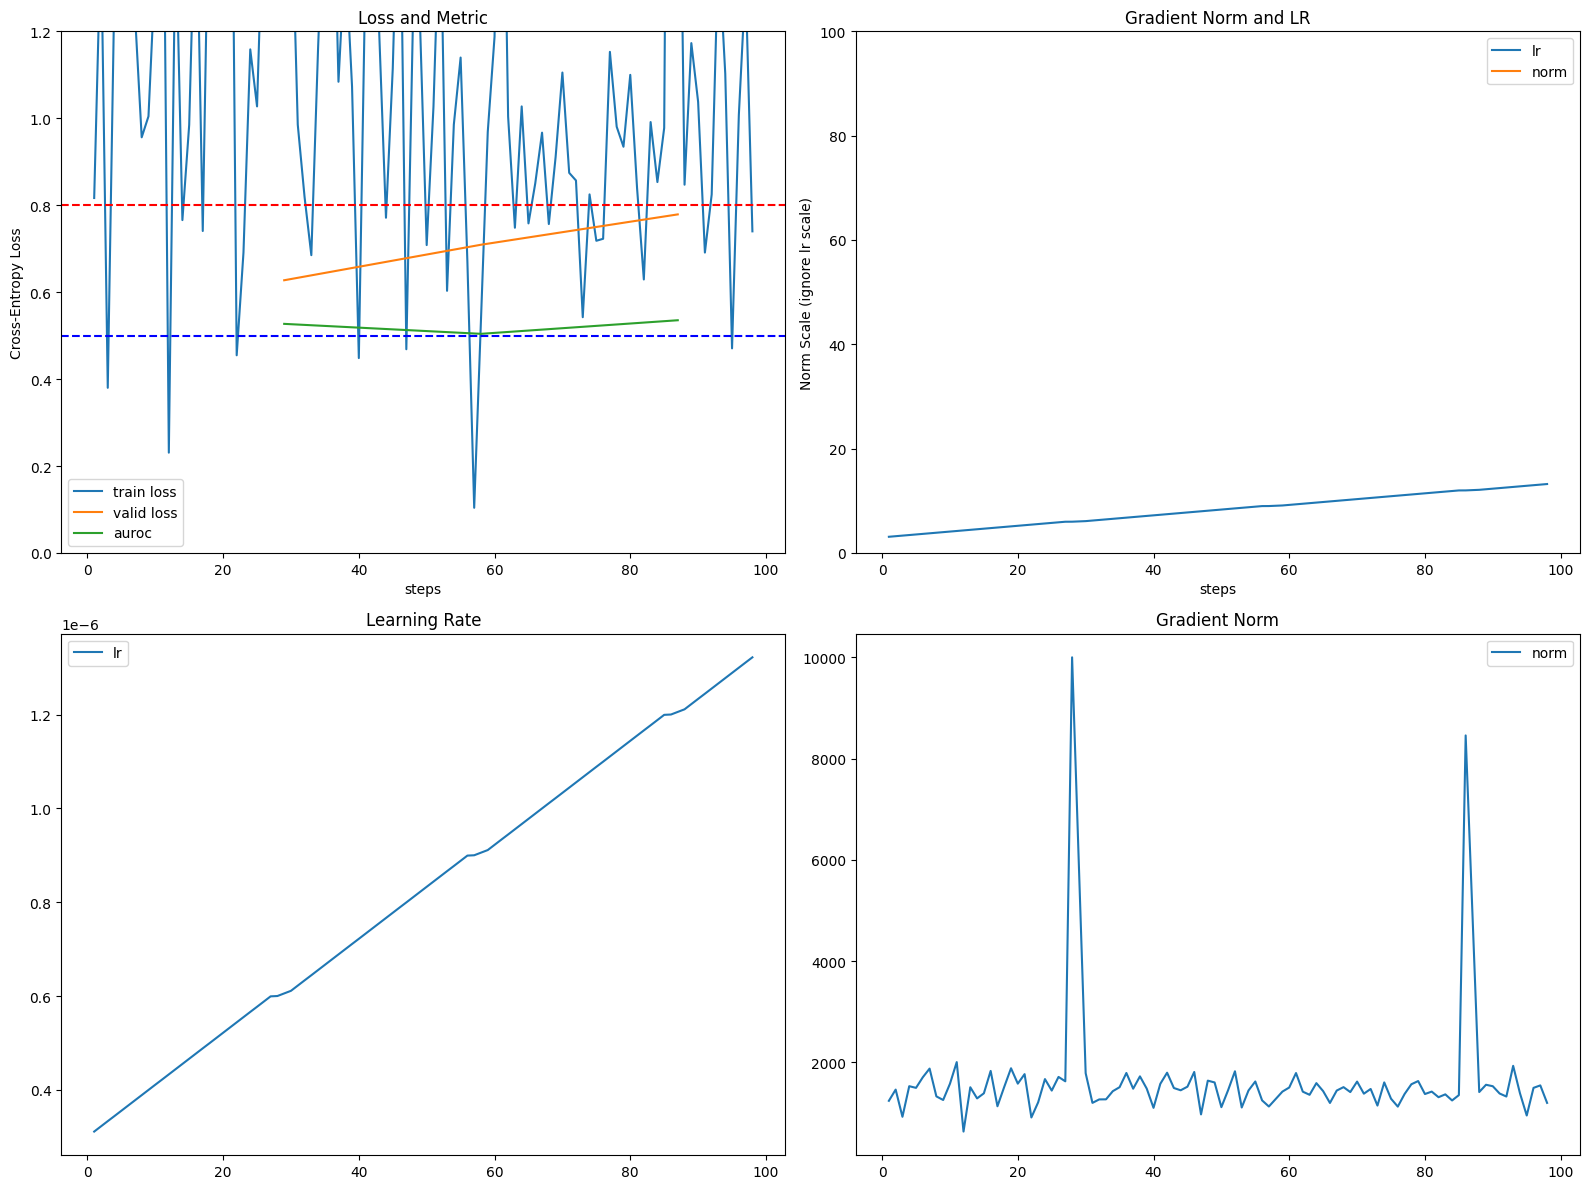

In [13]:
plot_log(
    "2025-02-13_10-59-49_debug_False_n_embed_256_n_head_8_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_7_lambda1_0.0_lambda2_1.0_epochs_100_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.6770833333333334


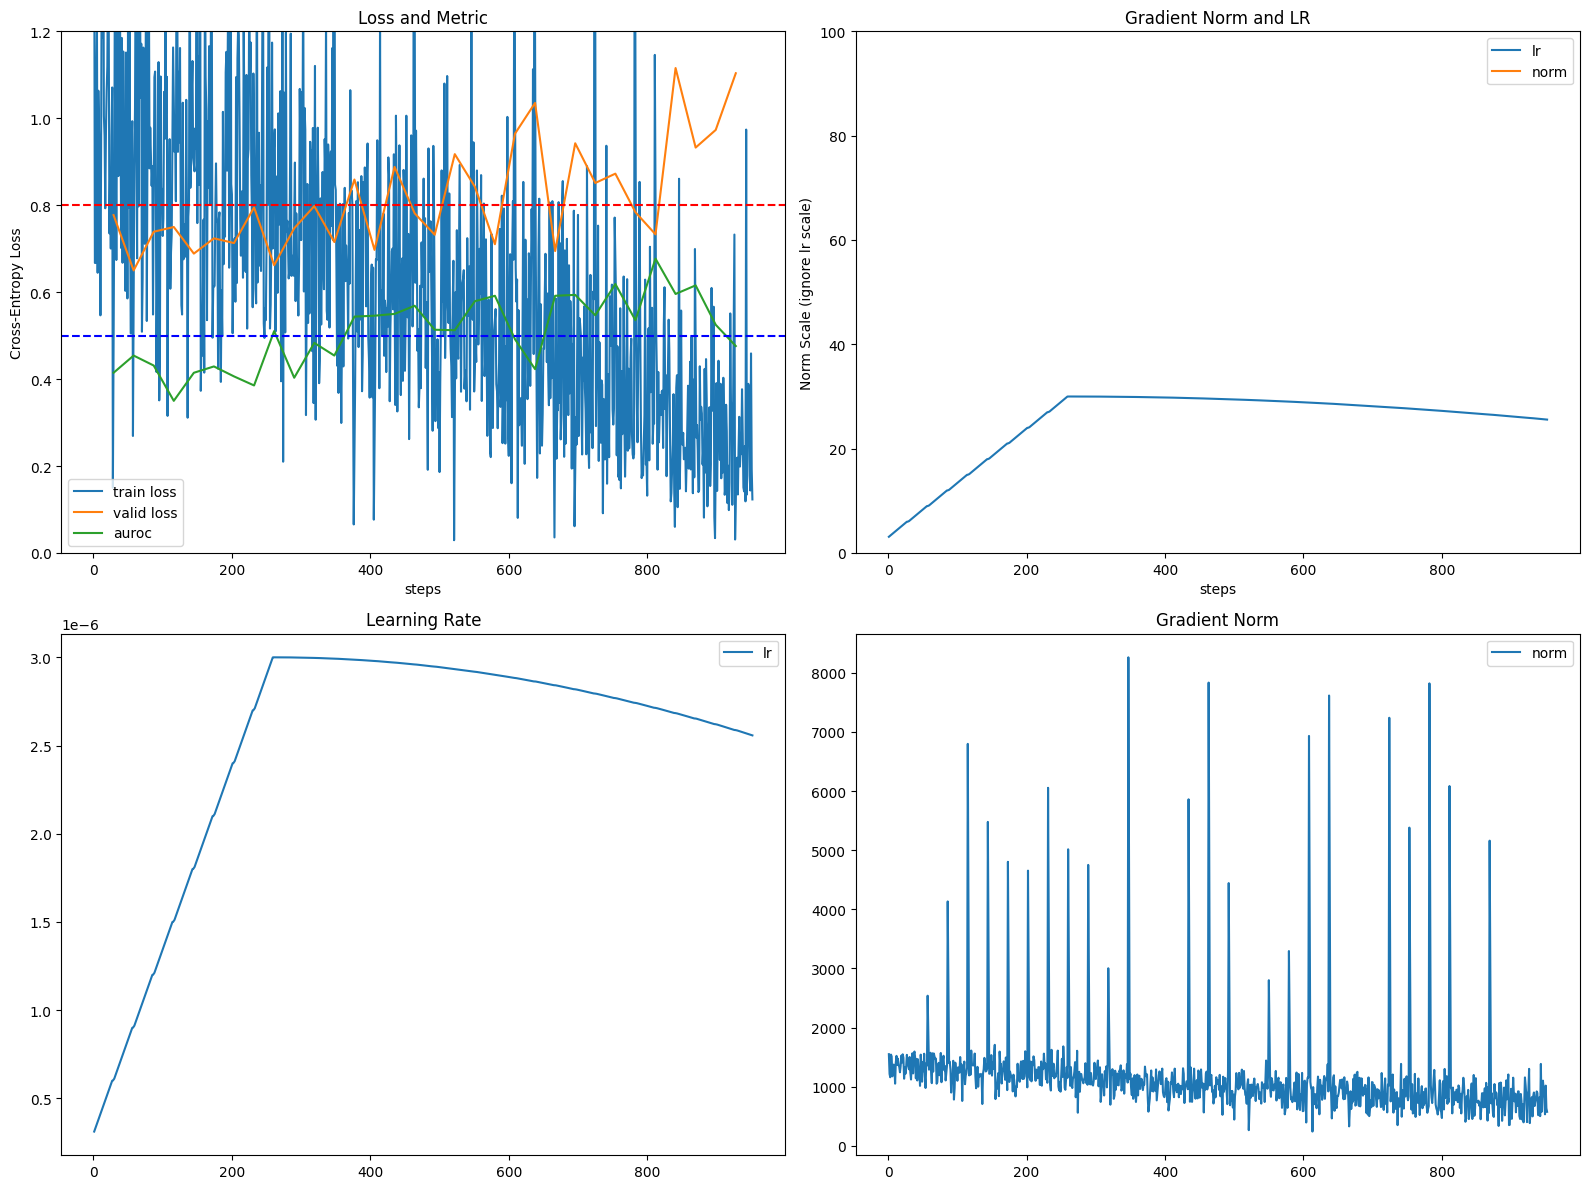

In [41]:
# gpu7_w_clip_init
plot_log(
    "2025-02-13_13-03-02_debug_False_n_embed_256_n_head_4_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_7_lambda1_0.0_lambda2_1.0_epochs_100_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.6333333333333334


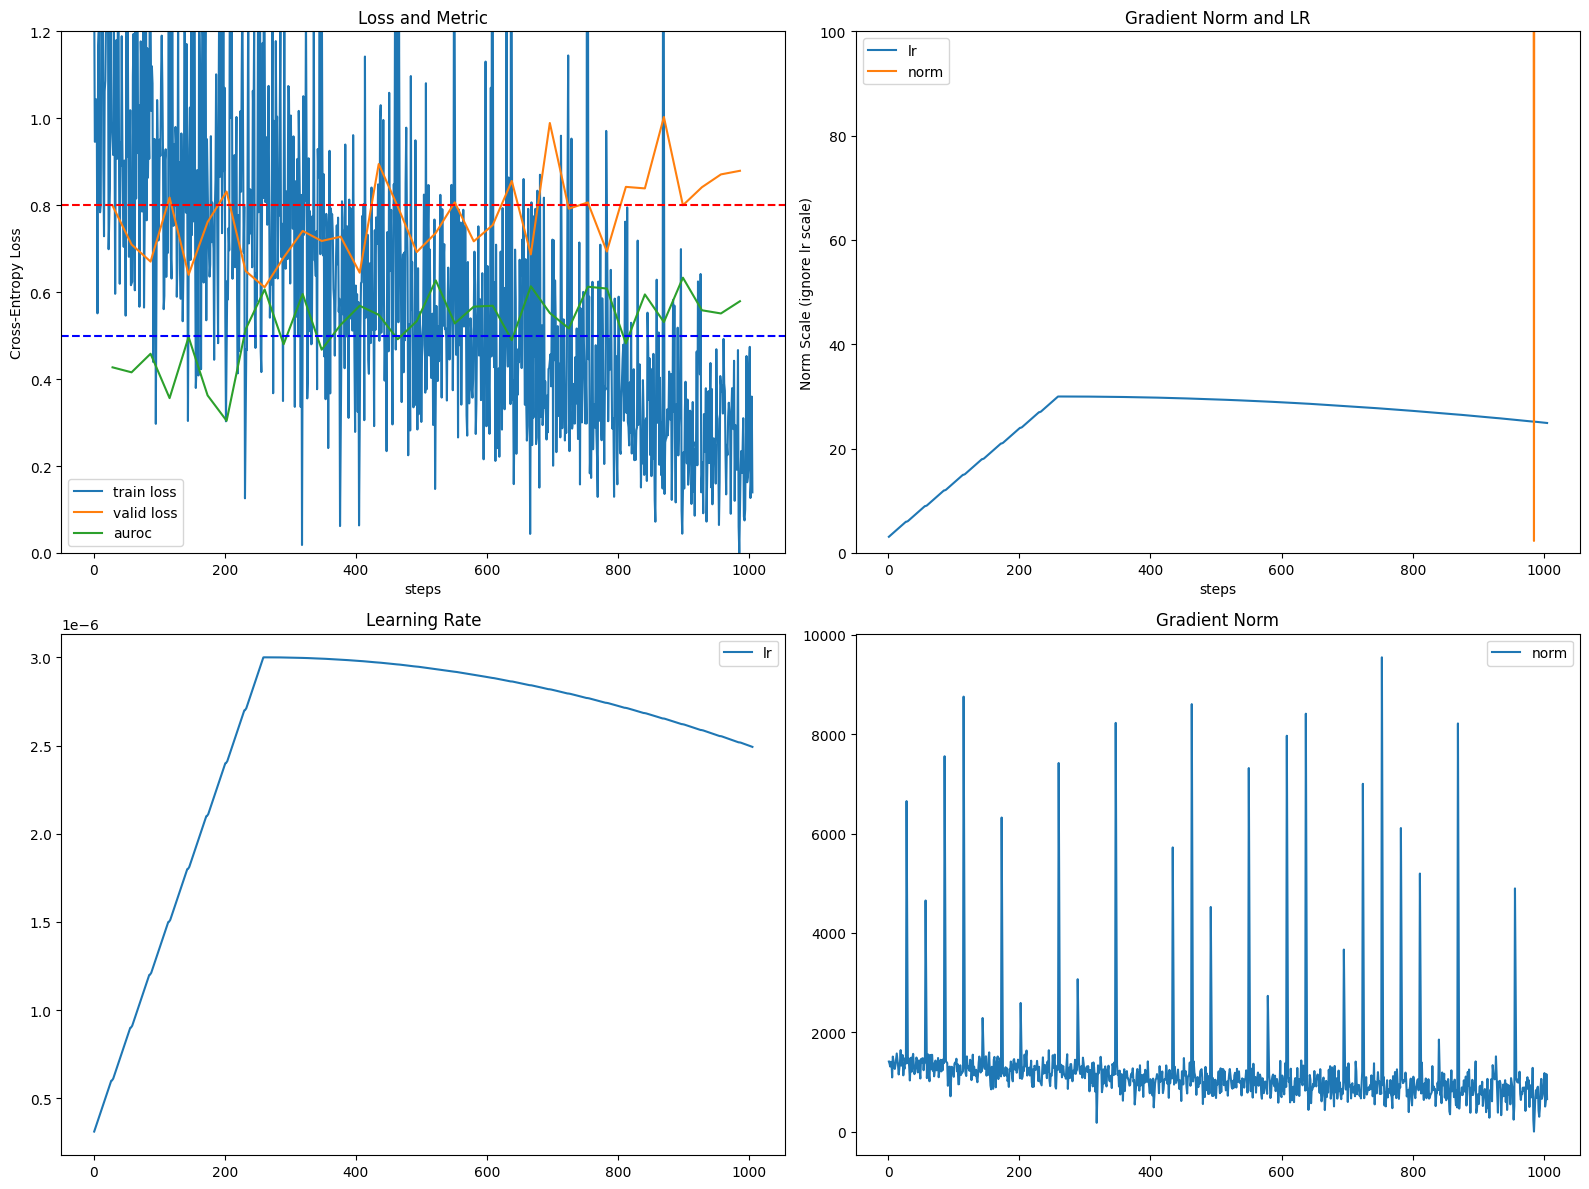

In [42]:
# gpu6_8head
plot_log(
    "2025-02-13_13-05-53_debug_False_n_embed_256_n_head_8_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_100_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.6083333333333334


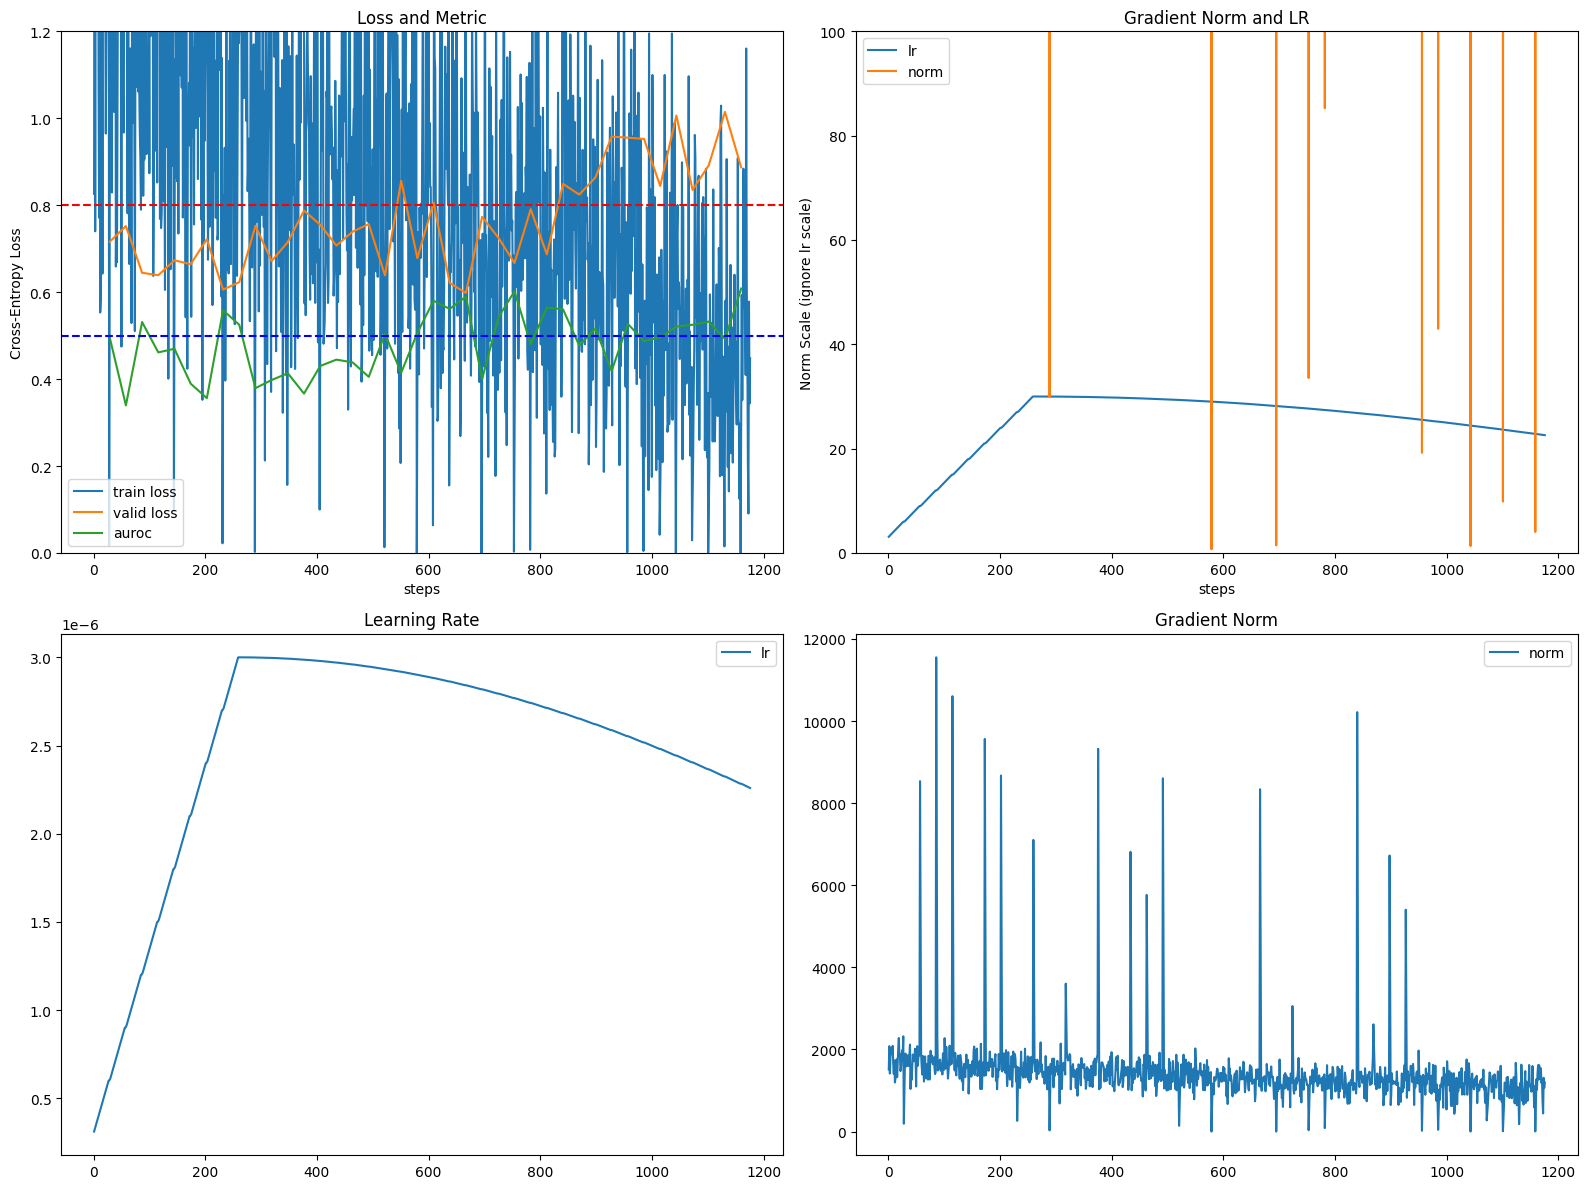

In [43]:
# gpu7_dropout
plot_log(
    "2025-02-13_13-24-58_debug_False_n_embed_256_n_head_4_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_7_lambda1_0.0_lambda2_1.0_epochs_100_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.6208333333333333


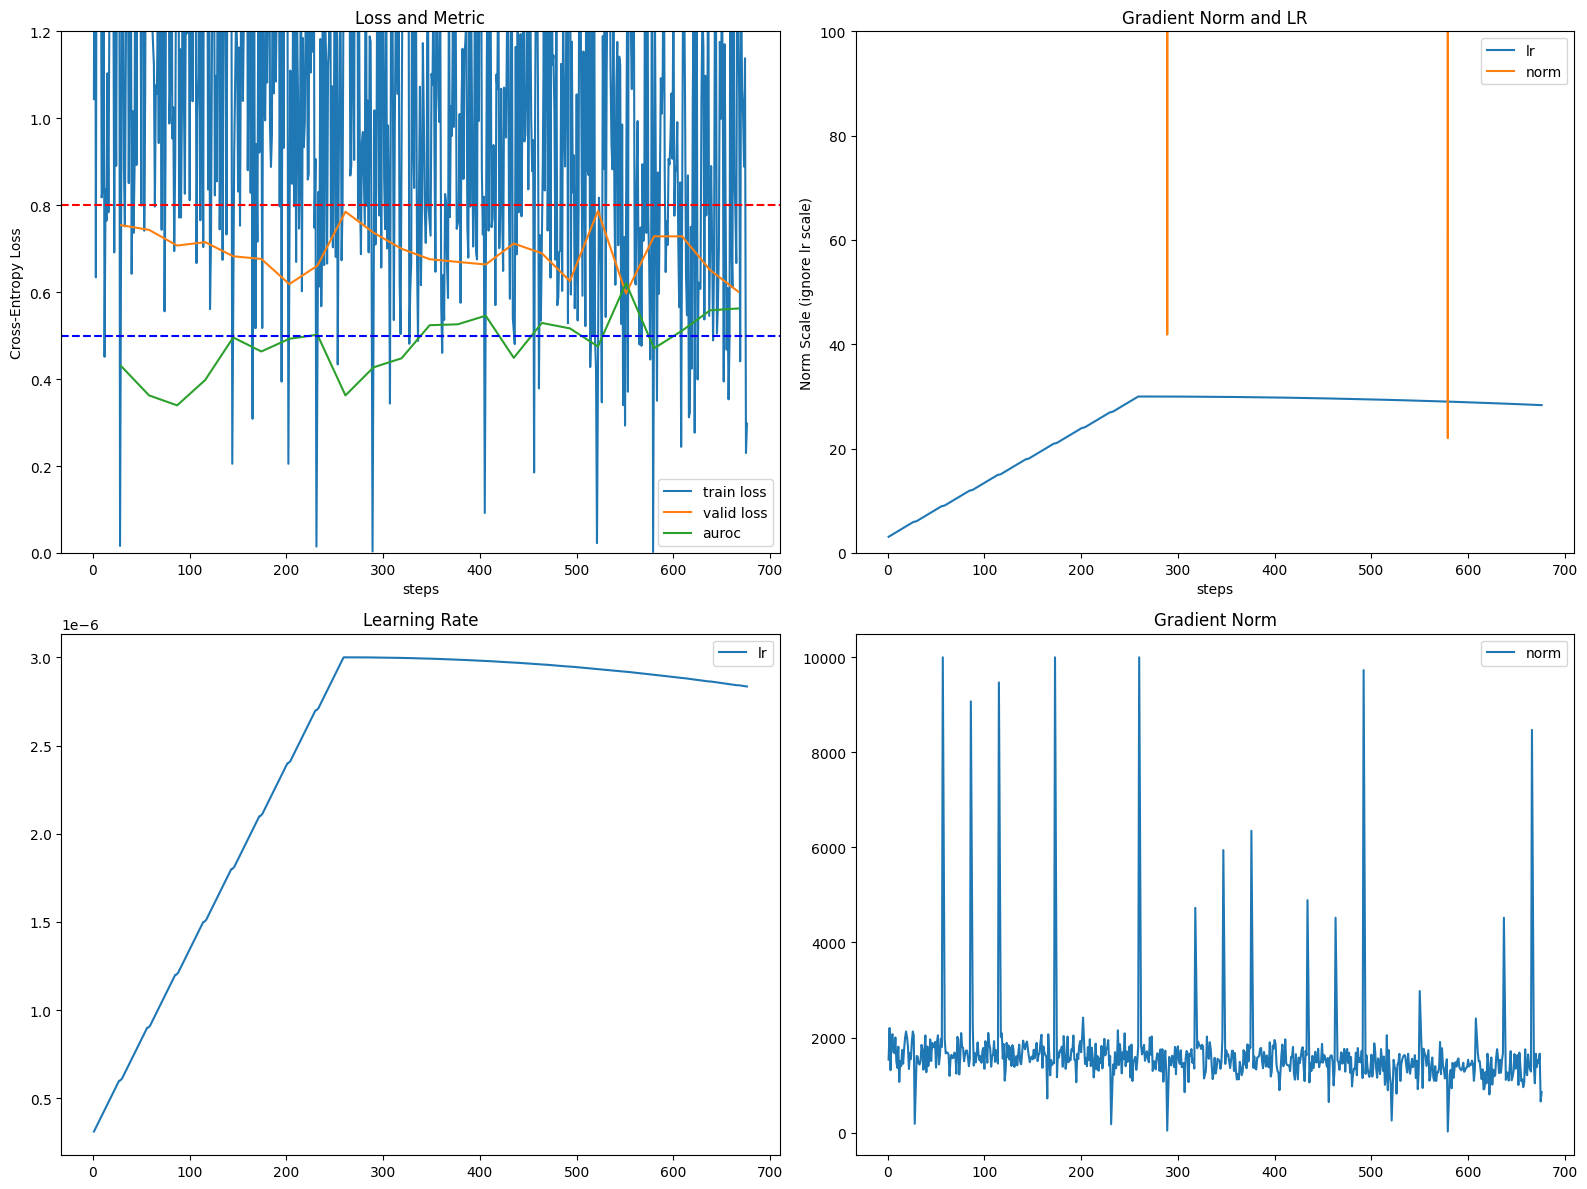

In [44]:
# gpu6_wo_clip
plot_log(
    "2025-02-13_21-56-56_debug_False_n_embed_256_n_head_4_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_100_lr_3e-06_batch_1_grad_accum_steps_16_eps_1e-06_resume_None"
)

Max auroc: 0.7760416666666667


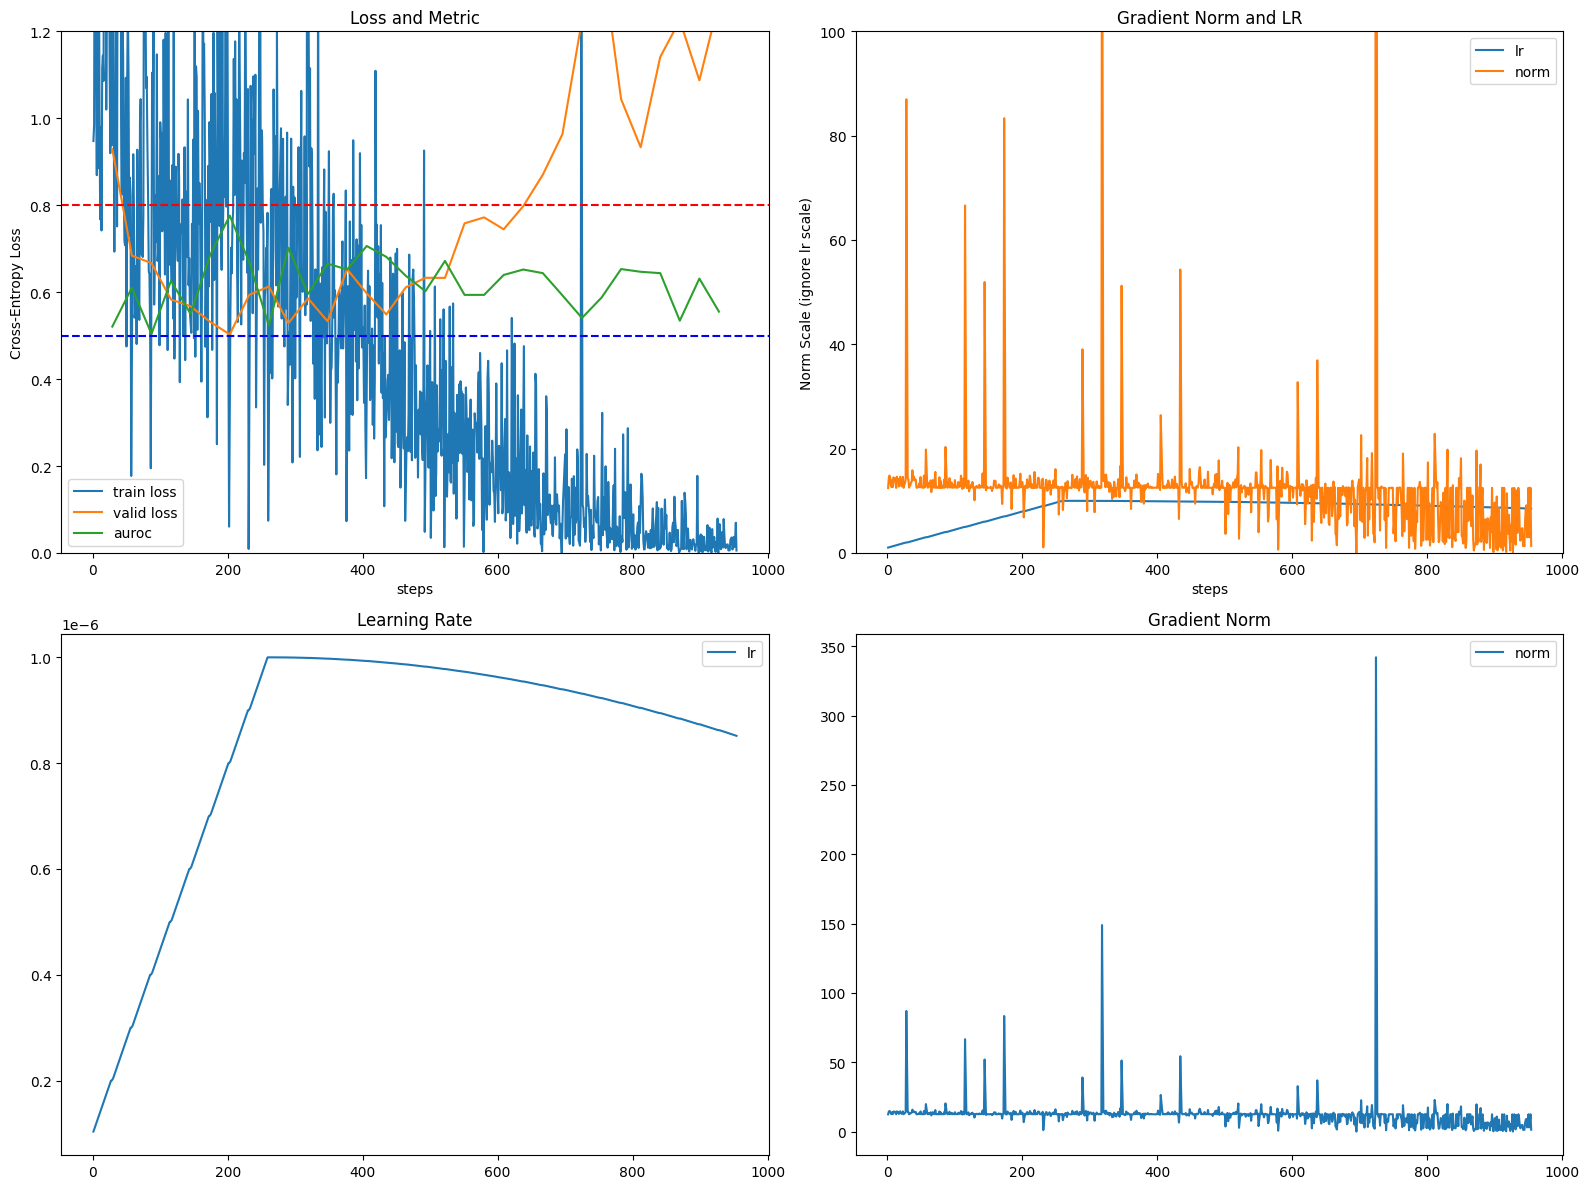

In [4]:
# gpu6_clip_1e-6
plot_log("2025-02-14_15-51-04_debug_False_n_embed_256_n_head_4_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_100_lr_1e-06_batch_1_grad_accum_steps_16_grad_clip_100_grad_threshold_150_eps_1e-06_resume_None")

Max auroc: 0.7416666666666667


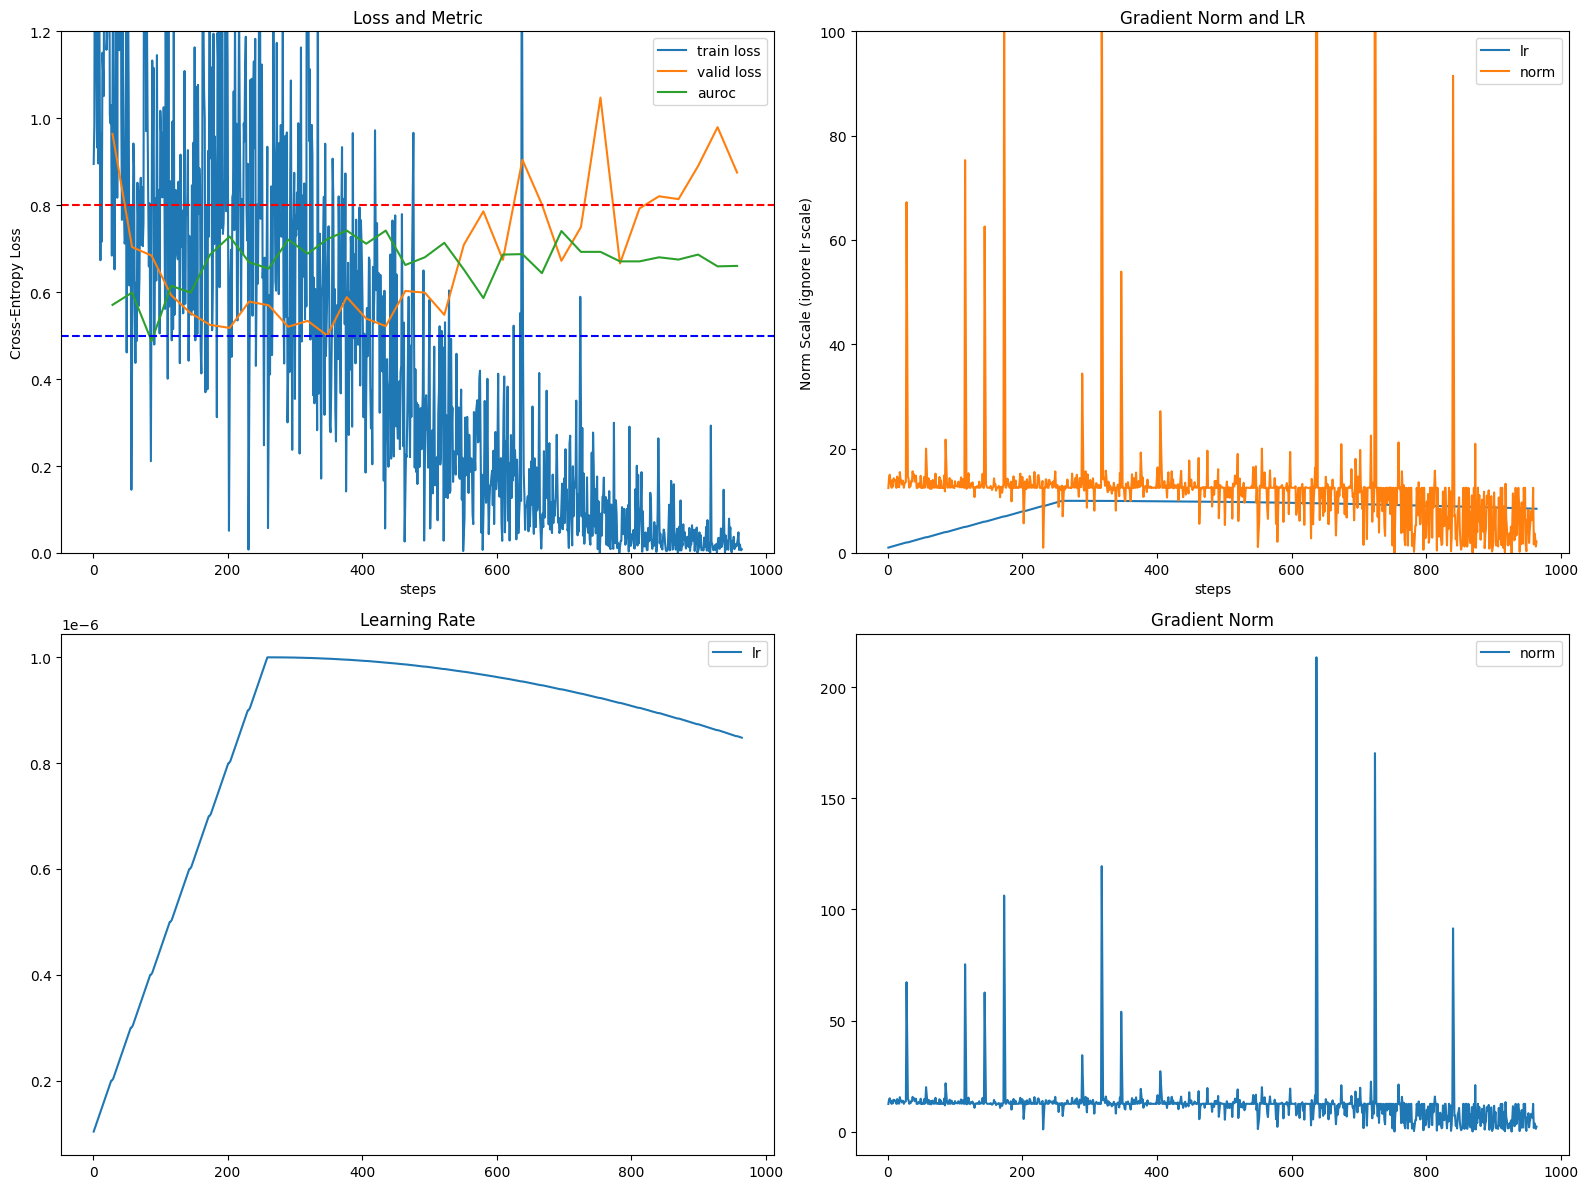

In [6]:
# gpu7_8head_1e-6
plot_log("2025-02-14_15-54-38_debug_False_n_embed_256_n_head_8_n_class_1_n_layer_2_width_2d_1024_width_3d_512_gpu_6_lambda1_0.0_lambda2_1.0_epochs_100_lr_1e-06_batch_1_grad_accum_steps_16_grad_clip_100_grad_threshold_150_eps_1e-06_resume_None")